# Bulk RNA-seq Mutation & CNV Integration for LUAD

This notebook downloads (or reuses pre-downloaded) somatic mutation (MAF) and gene-level copy number variation (CNV) data 
for three LUAD datasets — **TCGA-LUAD**, **CPTAC-3**, **CDDP_EAGLE-1** — from the NCI GDC Data Portal.

It then:
1. Builds patient-level binary mutation matrices for 14 lung cancer driver genes
2. Builds patient-level CNV matrices (ASCAT absolute copy number) for the same genes
3. Maps all patient identifiers to a consistent format matching the bulk RNA-seq metadata
4. Integrates mutation and CNV annotations into the merged `LUAD_BulkRNA_merged` SummarizedExperiment object
5. Saves `LUAD_BulkRNA_merged_withMutations.rds` for downstream analysis

**Key design decisions:**
- MAF files are read manually (not via `GDCprepare`) for robustness
- CNV file ↔ patient mapping uses the GDC `/files` API with `expand=cases`
- CPTAC ID mapping: GDC sample barcode (CPTxxxx) → case submitter_id (C3N-xxxxx)
- Only patient IDs matching the RNA-seq submitter_id format are retained
- CNV values are **ASCAT absolute copy numbers** (0 = homdel, 1 = hetloss, 2 = diploid, ≥3 = gain/amp)

## 0. Setup

In [1]:
library(TCGAbiolinks)
library(SummarizedExperiment)
library(dplyr)
library(tidyr)
library(stringr)
library(httr)
library(jsonlite)

# ── Paths ──────────────────────────────────────────────────
data_dir <- "/public/home/liwang/data/GDCdata2"
obj_dir  <- "/public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v6/objects"

# ── Target genes (14 LUAD drivers) ─────────────────────────
target_genes <- c(
  "ALK", "ERBB2", "EGFR", "KRAS", "TP53", "STK11", "KEAP1",
  "MET", "BRAF", "ROS1", "RET", "NTRK1", "NTRK2", "NTRK3"
)

# ── Projects ───────────────────────────────────────────────
projects <- c("TCGA-LUAD", "CPTAC-3", "CDDP_EAGLE-1")

# ── Non-synonymous variant classifications ─────────────────
nonsynonymous_classes <- c(
  "Missense_Mutation", "Nonsense_Mutation", 
  "Frame_Shift_Del", "Frame_Shift_Ins",
  "In_Frame_Del", "In_Frame_Ins",
  "Splice_Site", "Translation_Start_Site",
  "Nonstop_Mutation"
)

cat("Target genes (", length(target_genes), "): ", 
    paste(target_genes, collapse = ", "), "\n", sep = "")
cat("Projects: ", paste(projects, collapse = ", "), "\n", sep = "")

载入需要的程辑包：MatrixGenerics

载入需要的程辑包：matrixStats


载入程辑包：‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges, rowRanks,
    rowSdDiffs, rowSds, rowSums2, rowTabulates, rowVarDiffs, rowVars,
    rowWeight

Target genes (14): ALK, ERBB2, EGFR, KRAS, TP53, STK11, KEAP1, MET, BRAF, ROS1, RET, NTRK1, NTRK2, NTRK3
Projects: TCGA-LUAD, CPTAC-3, CDDP_EAGLE-1



载入程辑包：‘MatrixGenerics’




The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges, rowRanks,
    rowSdDiffs, rowSds, rowSums2, rowTabulates, rowVarDiffs, rowVars,
    rowWeightedMads, rowWeightedMeans, rowWeightedMedians,
    rowWeightedSds, rowWeig

载入需要的程辑包：GenomicRanges



...

The following object is masked from ‘package:S4Vectors’:

    expand





载入程辑包：‘httr’




The following object is masked from ‘package:Biobase’:

    content




Target genes (14): ALK, ERBB2, EGFR, KRAS, TP53, STK11, KEAP1, MET, BRAF, ROS1, RET, NTRK1, NTRK2, NTRK3


Projects: TCGA-LUAD, CPTAC-3, CDDP_EAGLE-1


## 1a. Download Somatic Mutation (MAF) Data

Query and download **Masked Somatic Mutation** MAF files from GDC for all three projects.
If files already exist locally, the download step is skipped automatically by `GDCdownload`.

**Data source:** GDC harmonized MAF files (Aliquot Ensemble Somatic Variant Merging and Masking pipeline).

In [2]:
# Safe download wrapper with retry logic
safe_GDCdownload <- function(query, directory, files.per.chunk = 50,
                             sleep_seconds = 60, max_attempts = 5) {
  attempt <- 1
  repeat {
    message("GDCdownload attempt: ", attempt)
    ok <- tryCatch({
      GDCdownload(query = query, directory = directory, 
                  files.per.chunk = files.per.chunk)
      TRUE
    }, error = function(e) {
      message("Download failed: ", conditionMessage(e))
      FALSE
    })
    if (ok) {
      message("GDCdownload finished successfully.")
      break
    }
    attempt <- attempt + 1
    if (attempt > max_attempts) {
      stop("GDCdownload failed after ", max_attempts, " attempts.")
    }
    message("Retrying in ", sleep_seconds, " seconds...")
    Sys.sleep(sleep_seconds)
  }
}

# Query and download MAF for each project
maf_queries <- list()

for (proj in projects) {
  cat("\n", paste(rep("=", 60), collapse = ""), "\n")
  cat("Querying MAF for project:", proj, "\n")
  
  query_maf <- GDCquery(
    project       = proj,
    data.category = "Simple Nucleotide Variation",
    data.type     = "Masked Somatic Mutation",
    access        = "open",
    workflow.type = "Aliquot Ensemble Somatic Variant Merging and Masking"
  )
  
  cat("MAF files found:", nrow(getResults(query_maf)), "\n")
  
  # Save query for later use (ID mapping)
  query_file <- file.path(obj_dir, paste0(proj, "_maf_query.rds"))
  saveRDS(query_maf, query_file)
  
  # Download
  safe_GDCdownload(
    query    = query_maf,
    directory = data_dir,
    files.per.chunk = 50
  )
  
  maf_queries[[proj]] <- query_maf
}

cat("\nAll MAF downloads complete.\n")


Querying MAF for project: TCGA-LUAD 


--------------------------------------



o GDCquery: Searching in GDC database



--------------------------------------



Genome of reference: hg38



...

GDCdownload attempt: 1



Of the 50 files for download 50 already exist.



All samples have been already downloaded



GDCdownload finished successfully.




All MAF downloads complete.


## 1b. Download Gene Level Copy Number Data

Query and download **Gene Level Copy Number** (ASCAT-derived absolute copy number) from GDC.

In [3]:
# Query and download Gene Level Copy Number for each project
cnv_queries <- list()

for (proj in projects) {
  cat("\n", paste(rep("=", 60), collapse = ""), "\n")
  cat("Querying CNV for project:", proj, "\n")
  
  query_cnv <- GDCquery(
    project       = proj,
    data.category = "Copy Number Variation",
    data.type     = "Gene Level Copy Number",
    access        = "open"
  )
  
  res <- getResults(query_cnv)
  cat("Gene Level CNV files found:", nrow(res), "\n")
  
  # Save query
  query_file <- file.path(obj_dir, paste0(proj, "_cnv_query.rds"))
  saveRDS(query_cnv, query_file)
  
  # Download
  safe_GDCdownload(
    query    = query_cnv,
    directory = data_dir,
    files.per.chunk = 50
  )
  
  cnv_queries[[proj]] <- query_cnv
}

cat("\nAll CNV downloads complete.\n")


Querying CNV for project: TCGA-LUAD 


--------------------------------------



o GDCquery: Searching in GDC database



--------------------------------------



Genome of reference: hg38



...

GDCdownload attempt: 1



Of the 44 files for download 44 already exist.



All samples have been already downloaded



GDCdownload finished successfully.




All CNV downloads complete.


## 1c. Read MAF Files & Build Mutation Matrix

Read MAF files manually from the harmonized GDC directories (more robust than `GDCprepare`
for the non-TCGA projects).  Filter to 14 target lung cancer driver genes and
non-synonymous variants only (Missense, Nonsense, Frame_Shift, In_Frame,
Splice_Site, Translation_Start_Site, Nonstop_Mutation).

**Patient ID extraction (dataset-specific):**
- **TCGA**: `Tumor_Sample_Barcode` → first 12 characters (e.g. `TCGA-78-7158`)
- **CPTAC**: `Tumor_Sample_Barcode` is a GDC sample barcode (`CPT0245180009`) →
  needs mapping to `case.submitter_id` (C3N-xxxxx), deferred to Phase 2b
- **CDDP**: `Tumor_Sample_Barcode` → first two dash-segments (e.g. `CDDP-ABIX`)

CPTAC mutation matrix is built in Phase 2b after ID mapping is established.

In [2]:
# Helper: read all MAF files from a harmonized GDC directory
read_maf_files <- function(proj, data_dir) {
  maf_dir <- file.path(data_dir, proj, "harmonized",
                       "Simple_Nucleotide_Variation",
                       "Masked_Somatic_Mutation")
  
  if (!dir.exists(maf_dir)) {
    cat("MAF directory not found:", maf_dir, "\n")
    return(NULL)
  }
  
  maf_files <- list.files(maf_dir, pattern = "\\.maf\\.gz$|\\.maf$",
                          recursive = TRUE, full.names = TRUE)
  cat("Found", length(maf_files), "MAF files\n")
  
  if (length(maf_files) == 0) return(NULL)
  
  maf_list <- list()
  for (i in seq_along(maf_files)) {
    if (i %% 500 == 0) cat("  Reading file", i, "of", length(maf_files), "\n")
    tryCatch({
      maf_list[[i]] <- read.delim(maf_files[i], comment.char = "#",
                                  stringsAsFactors = FALSE)
    }, error = function(e) {
      cat("  Error reading file", i, ":", conditionMessage(e), "\n")
    })
  }
  
  cat("  Binding", length(maf_list), "files...\n")
  maf_all <- do.call(rbind, maf_list)
  cat("  Total variants:", nrow(maf_all), "\n")
  
  return(maf_all)
}

# ── Read MAF for all three projects ────────────────────────
maf_data <- list()

for (proj in projects) {
  cat("\n=== Reading MAF:", proj, "===\n")
  maf_data[[proj]] <- read_maf_files(proj, data_dir)
}

# Rename for clarity
tcga_maf  <- maf_data[["TCGA-LUAD"]]
cptac_maf <- maf_data[["CPTAC-3"]]
cddp_maf  <- maf_data[["CDDP_EAGLE-1"]]

cat("\n=== MAF summary ===\n")
cat("TCGA-LUAD:    ", nrow(tcga_maf),  "variants\n")
cat("CPTAC-3:      ", nrow(cptac_maf), "variants\n")
cat("CDDP_EAGLE-1: ", nrow(cddp_maf),  "variants\n")


=== Reading MAF: TCGA-LUAD ===
Found 618 MAF files
  Reading file 500 of 618 
  Binding 618 files...
  Total variants: 194729 

=== Reading MAF: CPTAC-3 ===
Found 1957 MAF files
  Reading file 500 of 1957 
  Reading file 1000 of 1957 
  Reading file 1500 of 1957 
  Binding 1957 files...
  Total variants: 528370 

=== Reading MAF: CDDP_EAGLE-1 ===
Found 50 MAF files
  Binding 50 files...
  Total variants: 22753 



=== MAF summary ===


TCGA-LUAD:     194729 variants


CPTAC-3:       528370 variants


CDDP_EAGLE-1:  22753 variants


In [3]:
# Build mutation binary matrix for TCGA and CDDP
# (CPTAC needs ID mapping first — done in Phase 2c)

build_mutation_matrix <- function(maf, dataset_label, target_genes,
                                  nonsynonymous_classes) {
  cat("\n=== ", dataset_label, " ===\n")
  cat("Total variants:", nrow(maf), "\n")
  
  # Check required columns
  required <- c("Hugo_Symbol", "Tumor_Sample_Barcode", "Variant_Classification")
  missing  <- setdiff(required, colnames(maf))
  if (length(missing) > 0) {
    cat("SKIPPING — missing columns:", paste(missing, collapse = ", "), "\n")
    return(NULL)
  }
  
  # Filter: target genes + nonsynonymous
  maf_filt <- maf %>%
    filter(Hugo_Symbol %in% target_genes,
           Variant_Classification %in% nonsynonymous_classes)
  cat("Nonsynonymous variants in target genes:", nrow(maf_filt), "\n")
  
  # Extract patient-level ID
  if (dataset_label == "TCGA_LUAD") {
    maf_filt$patient_id <- substr(maf_filt$Tumor_Sample_Barcode, 1, 12)
  } else if (dataset_label == "CDDP_EAGLE") {
    maf_filt$patient_id <- sub("^([^-]+-[^-]+).*", "\\1",
                               maf_filt$Tumor_Sample_Barcode)
  }
  
  cat("Unique patients with mutations:", length(unique(maf_filt$patient_id)), "\n")
  
  # Build binary matrix: patient × gene
  mut_mat <- maf_filt %>%
    select(patient_id, Hugo_Symbol) %>%
    distinct() %>%
    mutate(mutated = TRUE) %>%
    pivot_wider(
      id_cols     = patient_id,
      names_from  = Hugo_Symbol,
      values_from = mutated,
      values_fill = FALSE,
      names_prefix = "mut_"
    )
  
  # FIXED: Ensure all target genes have columns (even if zero mutations)
  for (g in target_genes) {
    col_name <- paste0("mut_", g)
    if (!col_name %in% colnames(mut_mat)) {
      mut_mat[[col_name]] <- FALSE
    }
  }
  
  cat("Mutation matrix:", nrow(mut_mat), "patients ×", ncol(mut_mat), "columns\n")
  
  # Frequency summary
  mut_cols <- grep("^mut_", colnames(mut_mat), value = TRUE)
  if (length(mut_cols) > 0) {
    freq <- colSums(mut_mat[, mut_cols, drop = FALSE], na.rm = TRUE)
    cat("Top mutations:\n")
    print(sort(freq, decreasing = TRUE))
  }
  
  return(mut_mat)
}

# ── Build matrices for TCGA and CDDP ──────────────────────
mutation_matrix_list <- list()

mutation_matrix_list[["TCGA_LUAD"]] <- build_mutation_matrix(
  tcga_maf, "TCGA_LUAD", target_genes, nonsynonymous_classes
)

# For CDDP, ensure patient_id matches RNA submitter_id format (CDDP-XXXX)
mutation_matrix_list[["CDDP_EAGLE"]] <- build_mutation_matrix(
  cddp_maf, "CDDP_EAGLE", target_genes, nonsynonymous_classes
)

# CPTAC will be added after ID mapping
cat("\nCPTAC mutation matrix deferred to Phase 2c (ID mapping required).\n")


===  TCGA_LUAD  ===
Total variants: 194729 
Nonsynonymous variants in target genes: 1022 
Unique patients with mutations: 484 
Mutation matrix: 484 patients × 15 columns
Top mutations:
 mut_TP53  mut_KRAS mut_KEAP1  mut_EGFR mut_STK11 mut_NTRK3  mut_BRAF   mut_ALK 
      276       149        98        74        66        41        40        27 
 mut_ROS1 mut_NTRK2   mut_MET   mut_RET mut_ERBB2 mut_NTRK1 
       22        21        19        16        12        11 



===  CDDP_EAGLE  ===
Total variants: 22753 
Nonsynonymous variants in target genes: 101 
Unique patients with mutations: 46 
Mutation matrix: 46 patients × 15 columns
Top mutations:
 mut_TP53  mut_KRAS mut_STK11 mut_KEAP1 mut_NTRK3 mut_NTRK2  mut_ROS1   mut_ALK 
       24        21        15        10         7         6         3         2 
 mut_BRAF  mut_EGFR mut_NTRK1   mut_RET mut_ERBB2   mut_MET 
        2         2         2         1         1         0 



CPTAC mutation matrix deferred to Phase 2c (ID mapping required).


## 2a. Read CNV Files & Build CNV Matrix

Read GDC **Gene Level Copy Number** files (ASCAT absolute copy number) from the harmonized directories.
The file parent-directory name is the GDC file UUID — used as a key to map to patient IDs via query results.

**ASCAT absolute copy number semantics:**
- 0 = homozygous deletion
- 1 = heterozygous loss  
- 2 = diploid / normal
- 3 = low-level gain
- ≥4 = amplification

**NOTE:** This step reads 3000+ CNV files and can take 5-10 minutes without cache.

In [ ]:
# Read CNV files, keeping only target genes.
# The parent directory of each CNV file is the GDC file UUID,
# which matches the 'id' column in query results.
# 
# NOTE: This step reads 3000+ CNV files and can take 5-10 minutes.
# If the intermediate RDS already exists, it is loaded from cache.

cnv_cache_path <- file.path(obj_dir, "cnv_with_fid_cache.rds")

if (file.exists(cnv_cache_path)) {
  cat("Loading cached CNV data from:", cnv_cache_path, "\n")
  cnv_with_fid <- readRDS(cnv_cache_path)
  for (proj in projects) {
    if (!is.null(cnv_with_fid[[proj]])) {
      cat(sprintf("  %s: %d records loaded\n", proj, nrow(cnv_with_fid[[proj]])))
    }
  }
} else {
  read_cnv_with_fid <- function(proj, data_dir, target_genes) {
    cnv_dir <- file.path(data_dir, proj, "harmonized",
                         "Copy_Number_Variation", "Gene_Level_Copy_Number")
    
    if (!dir.exists(cnv_dir)) {
      cat("  CNV directory not found:", cnv_dir, "\n")
      return(NULL)
    }
    
    all_files <- list.files(cnv_dir, pattern = "\\.tsv\\.gz$|\\.tsv$",
                            recursive = TRUE, full.names = TRUE)
    cat("  Scanning", length(all_files), "CNV files...\n")
    
    results <- list()
    kept <- 0
    n_total <- length(all_files)
    
    for (i in seq_along(all_files)) {
      # Progress every 400 files
      if (i %% 400 == 0) cat(sprintf("    File %d of %d (%.0f%%), kept %d so far\n", 
                                      i, n_total, i/n_total*100, kept))
      
      cnv <- tryCatch(
        read.delim(all_files[i], stringsAsFactors = FALSE),
        error = function(e) NULL
      )
      if (is.null(cnv) || nrow(cnv) == 0 || !"gene_name" %in% colnames(cnv)) next
      
      # Filter to target genes
      cnv_target <- cnv[cnv$gene_name %in% target_genes, , drop = FALSE]
      if (nrow(cnv_target) == 0) next
      
      # Extract file_id from parent directory name (the UUID)
      fpath_parts <- strsplit(all_files[i], "/")[[1]]
      file_id <- fpath_parts[length(fpath_parts) - 1]
      
      cnv_target$file_id     <- file_id
      cnv_target$source_proj <- proj
      
      kept <- kept + 1
      results[[kept]] <- cnv_target
    }
    
    cat(sprintf("  Files with target genes: %d / %d\n", kept, n_total))
    if (length(results) == 0) {
      cat("  WARNING: No CNV files with target genes found\n")
      return(NULL)
    }
    
    cnv_all <- do.call(rbind, results)
    cat(sprintf("  Total records: %d\n", nrow(cnv_all)))
    
    return(cnv_all)
  }
  
  # ── Read CNV for all projects ──────────────────────────────
  cnv_with_fid <- list()
  for (proj in projects) {
    cat("\n=== CNV:", proj, "===\n")
    cnv_with_fid[[proj]] <- read_cnv_with_fid(proj, data_dir, target_genes)
  }
  
  # Save cache for future runs
  saveRDS(cnv_with_fid, cnv_cache_path)
  cat("\nCNV data cached to:", cnv_cache_path, "\n")
}

In [ ]:
# Build CNV patient × gene matrix for TCGA and CDDP
# Uses saved CNV query results (file_id → cases → patient_id)
# CPTAC will be built in Phase 2c after ID mapping

cnv_matrix_list <- list()

for (proj in c("TCGA-LUAD", "CDDP_EAGLE-1")) {
  cat("\n=== Building CNV matrix:", proj, "===\n")
  
  cnv_df <- cnv_with_fid[[proj]]
  if (is.null(cnv_df) || nrow(cnv_df) == 0) {
    cat("  No CNV data — skipping\n")
    next
  }
  
  # Load saved query for file_id → patient mapping
  query_file <- file.path(obj_dir, paste0(proj, "_cnv_query.rds"))
  if (!file.exists(query_file)) {
    cat("  Query file not found — skipping\n")
    next
  }
  query_cnv <- readRDS(query_file)
  res <- getResults(query_cnv)
  
  # Verify file_id match
  cnv_fids <- unique(cnv_df$file_id)
  matched  <- intersect(cnv_fids, res$id)
  cat("  file_id match rate:", round(length(matched) / length(cnv_fids) * 100, 1), "%\n")
  
  # Build file_id → patient_id mapping
  if (proj == "TCGA-LUAD") {
    # cases = aliquot barcode "TCGA-86-8358-01A-11D-2322-01" → first 12 chars
    id_to_patient <- setNames(substr(res$cases, 1, 12), res$id)
  } else if (proj == "CDDP_EAGLE-1") {
    # cases = "CDDP-ABIX-NB1-A-1-0-D-A500-36,..." → "CDDP-ABIX"
    res$sample_barcode <- sub(",.*", "", res$cases)
    id_to_patient <- setNames(
      sub("^(CDDP-[^-]+).*", "\\1", res$sample_barcode), res$id
    )
  }
  
  cnv_df$patient_id <- id_to_patient[cnv_df$file_id]
  cat("  Records with patient_id:", sum(!is.na(cnv_df$patient_id)),
      "/", nrow(cnv_df), "\n")
  cat("  Unique patients:", length(unique(na.omit(cnv_df$patient_id))), "\n")
  
  # Build CNV matrix: patient × gene, ASCAT absolute copy number
  # values_fill = 2 (diploid) as default
  # FIXED: max(NA, na.rm=TRUE) returns -Inf; use NA_real_ when all values are NA
  cnv_wide <- cnv_df %>%
    filter(!is.na(patient_id)) %>%
    select(patient_id, gene_name, copy_number) %>%
    group_by(patient_id, gene_name) %>%
    summarise(
      copy_number = if (all(is.na(copy_number))) NA_real_ 
                    else max(copy_number, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    pivot_wider(
      id_cols     = patient_id,
      names_from  = gene_name,
      values_from = copy_number,
      values_fill = 2,          # diploid as default
      names_prefix = "cna_"
    )
  
  cnv_matrix_list[[proj]] <- cnv_wide
  cat("  CNV matrix:", nrow(cnv_wide), "patients ×", ncol(cnv_wide), "columns\n")
}

# Save intermediate
saveRDS(cnv_matrix_list, file.path(obj_dir, "cnv_matrix_list.rds"))
cat("\nPartial CNV matrix list saved (CPTAC pending).\n")

## 2b. CPTAC ID Mapping

CPTAC has two different identifier systems that must be reconciled:
- **GDC sample barcode**: `CPT0245180009` (used in MAF `Tumor_Sample_Barcode` and CNV `cases` column)
- **Case submitter_id**: `C3N-03015` (used in RNA-seq `submitter_id`)

**Mapping strategy:** Use the GDC `/files` API with `expand=cases` to get `case.submitter_id` for each file UUID.
This is applied to both MAF and CNV file sets, yielding C3N-format patient IDs that match the RNA-seq metadata.

In [8]:
# ── CPTAC MAF: file UUID → case.submitter_id via GDC /files API ──
# Each MAF file (in its own directory named by UUID) belongs to one case
# We query GDC /files?expand=cases to get cases.submitter_id

maf_query <- readRDS(file.path(obj_dir, "CPTAC-3_maf_query.rds"))
maf_res   <- getResults(maf_query)
file_ids  <- maf_res$id

fid_to_case_maf <- list()
batch_size <- 100

cat("Querying GDC /files for CPTAC MAF (", length(file_ids), " files)...\n", sep = "")

for (start in seq(1, length(file_ids), batch_size)) {
  end   <- min(start + batch_size - 1, length(file_ids))
  batch <- file_ids[start:end]
  
  filters <- list(
    op = "in",
    content = list(
      field = "files.file_id",
      value = as.list(batch)
    )
  )
  
  url <- paste0(
    "https://api.gdc.cancer.gov/files?",
    "filters=", URLencode(toJSON(filters, auto_unbox = TRUE)),
    "&expand=cases",
    "&fields=cases.submitter_id",
    "&size=", batch_size,
    "&format=JSON"
  )
  
  resp <- tryCatch(GET(url, timeout(60)), error = function(e) NULL)
  
  if (!is.null(resp) && status_code(resp) == 200) {
    data <- fromJSON(content(resp, "text", encoding = "UTF-8"))
    hits <- data$data$hits
    if (length(hits) > 0 && is.data.frame(hits)) {
      for (i in seq_len(nrow(hits))) {
        cases_data <- hits$cases[i]
        if (is.list(cases_data) && length(cases_data[[1]]) > 0) {
          case_df <- cases_data[[1]]
          if (is.data.frame(case_df) && "submitter_id" %in% names(case_df)) {
            fid_to_case_maf[[hits$id[i]]] <- case_df$submitter_id[1]
          }
        }
      }
    }
  }
  
  if (start %% 500 == 1) {
    cat("  Batch", start, "-", end, "; mappings:", length(fid_to_case_maf), "\n")
  }
}

cat("CPTAC MAF file→case mappings:", length(fid_to_case_maf), "\n")
saveRDS(fid_to_case_maf, file.path(obj_dir, "cptac_maf_fid_to_case.rds"))

Querying GDC /files for CPTAC MAF (1957 files)...


  Batch 1 - 100 ; mappings: 100 
  Batch 501 - 600 ; mappings: 600 
  Batch 1001 - 1100 ; mappings: 1100 
  Batch 1501 - 1600 ; mappings: 1600 


CPTAC MAF file→case mappings: 1957 


In [9]:
# ── CPTAC CNV: file UUID → case.submitter_id via GDC /files API ──

cnv_query <- readRDS(file.path(obj_dir, "CPTAC-3_cnv_query.rds"))
cnv_res   <- getResults(cnv_query)
file_ids  <- cnv_res$id

fid_to_case_cnv <- list()
batch_size <- 100

cat("Querying GDC /files for CPTAC CNV (", length(file_ids), " files)...\n", sep = "")

for (start in seq(1, length(file_ids), batch_size)) {
  end   <- min(start + batch_size - 1, length(file_ids))
  batch <- file_ids[start:end]
  
  filters <- list(
    op = "in",
    content = list(
      field = "files.file_id",
      value = as.list(batch)
    )
  )
  
  url <- paste0(
    "https://api.gdc.cancer.gov/files?",
    "filters=", URLencode(toJSON(filters, auto_unbox = TRUE)),
    "&expand=cases",
    "&fields=cases.submitter_id",
    "&size=", batch_size,
    "&format=JSON"
  )
  
  resp <- tryCatch(GET(url, timeout(60)), error = function(e) NULL)
  
  if (!is.null(resp) && status_code(resp) == 200) {
    data <- fromJSON(content(resp, "text", encoding = "UTF-8"))
    hits <- data$data$hits
    if (length(hits) > 0 && is.data.frame(hits)) {
      for (i in seq_len(nrow(hits))) {
        cases_data <- hits$cases[i]
        if (is.list(cases_data) && length(cases_data[[1]]) > 0) {
          case_df <- cases_data[[1]]
          if (is.data.frame(case_df) && "submitter_id" %in% names(case_df)) {
            fid_to_case_cnv[[hits$id[i]]] <- case_df$submitter_id[1]
          }
        }
      }
    }
  }
  
  if (start %% 500 == 1) {
    cat("  Batch", start, "-", end, "; mappings:", length(fid_to_case_cnv), "\n")
  }
}

cat("CPTAC CNV file→case mappings:", length(fid_to_case_cnv), "\n")
saveRDS(fid_to_case_cnv, file.path(obj_dir, "cptac_cnv_fid_to_case.rds"))

Querying GDC /files for CPTAC CNV (1744 files)...


  Batch 1 - 100 ; mappings: 100 
  Batch 501 - 600 ; mappings: 600 
  Batch 1001 - 1100 ; mappings: 1100 
  Batch 1501 - 1600 ; mappings: 1600 


CPTAC CNV file→case mappings: 1744 


In [ ]:
# ── Build CPTAC Mutation Matrix (using MAF file → case.submitter_id mapping) ──

fid_to_case_maf <- readRDS(file.path(obj_dir, "cptac_maf_fid_to_case.rds"))

maf_dir <- file.path(data_dir, "CPTAC-3", "harmonized",
                     "Simple_Nucleotide_Variation", "Masked_Somatic_Mutation")
maf_files <- list.files(maf_dir, pattern = "\\.maf\\.gz$",
                        recursive = TRUE, full.names = TRUE)

cat("Re-reading CPTAC MAF files with case.submitter_id mapping...\n")

maf_with_case <- list()
kept <- 0

for (i in seq_along(maf_files)) {
  if (i %% 400 == 0) cat("  File", i, "of", length(maf_files), "\n")
  
  # Get file UUID from parent directory
  fpath_parts <- strsplit(maf_files[i], "/")[[1]]
  file_id <- fpath_parts[length(fpath_parts) - 1]
  
  case_sid <- fid_to_case_maf[[file_id]]
  if (is.null(case_sid)) next
  
  maf <- tryCatch(
    read.delim(maf_files[i], comment.char = "#", stringsAsFactors = FALSE),
    error = function(e) NULL
  )
  if (is.null(maf) || nrow(maf) == 0) next
  
  # Filter: target genes + nonsynonymous
  maf_target <- maf %>%
    filter(Hugo_Symbol %in% target_genes,
           Variant_Classification %in% nonsynonymous_classes)
  
  if (nrow(maf_target) == 0) next
  
  maf_target$case_submitter_id <- case_sid
  kept <- kept + 1
  maf_with_case[[kept]] <- maf_target
}

cat("Files with target mutations:", kept, "\n")
cptac_maf_mapped <- do.call(rbind, maf_with_case)
cat("Total nonsynonymous target mutations:", nrow(cptac_maf_mapped), "\n")

# Filter: only keep C3N/C3L format patient IDs
cptac_maf_mapped <- cptac_maf_mapped %>%
  filter(grepl("^C3[LN]-", case_submitter_id))

cat("After filtering to C3N/C3L format:", nrow(cptac_maf_mapped), "mutations\n")
cat("Unique cases:", length(unique(cptac_maf_mapped$case_submitter_id)), "\n")

# Build mutation matrix
cptac_mut <- cptac_maf_mapped %>%
  select(patient_id = case_submitter_id, Hugo_Symbol) %>%
  distinct() %>%
  mutate(mutated = TRUE) %>%
  pivot_wider(
    id_cols     = patient_id,
    names_from  = Hugo_Symbol,
    values_from = mutated,
    values_fill = FALSE,
    names_prefix = "mut_"
  )

# FIXED: Ensure all target genes have columns (even if zero mutations)
for (g in target_genes) {
  col_name <- paste0("mut_", g)
  if (!col_name %in% colnames(cptac_mut)) {
    cptac_mut[[col_name]] <- FALSE
  }
}

cat("CPTAC mutation matrix:", nrow(cptac_mut), "patients ×",
    ncol(cptac_mut), "columns\n")

mutation_matrix_list[["CPTAC"]] <- cptac_mut

# Save updated mutation list
saveRDS(mutation_matrix_list, file.path(obj_dir, "mutation_matrix_list.rds"))
cat("Mutation matrix list saved.\n")

In [ ]:
# ── Build CPTAC CNV Matrix (using CNV file → case.submitter_id mapping) ──

fid_to_case_cnv <- readRDS(file.path(obj_dir, "cptac_cnv_fid_to_case.rds"))

cptac_cnv <- cnv_with_fid[["CPTAC-3"]]
cptac_cnv$case_submitter_id <- unname(unlist(fid_to_case_cnv[cptac_cnv$file_id]))

cat("CNV records with case_submitter_id:", 
    sum(!is.na(cptac_cnv$case_submitter_id)), "/", nrow(cptac_cnv), "\n")

# Filter: only keep C3N/C3L format patient IDs
cptac_cnv_filt <- cptac_cnv %>%
  filter(!is.na(case_submitter_id),
         grepl("^C3[LN]-", case_submitter_id))

cat("After filtering to C3N/C3L:", nrow(cptac_cnv_filt), "records\n")
cat("Unique cases:", length(unique(cptac_cnv_filt$case_submitter_id)), "\n")

# Build CNV matrix
# FIXED: max(NA, na.rm=TRUE) returns -Inf; use NA_real_ when all values are NA
cptac_cnv_wide <- cptac_cnv_filt %>%
  select(patient_id = case_submitter_id, gene_name, copy_number) %>%
  group_by(patient_id, gene_name) %>%
  summarise(
    copy_number = if (all(is.na(copy_number))) NA_real_ 
                  else max(copy_number, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  pivot_wider(
    id_cols     = patient_id,
    names_from  = gene_name,
    values_from = copy_number,
    values_fill = 2,          # diploid as default
    names_prefix = "cna_"
  )

cat("CPTAC CNV matrix:", nrow(cptac_cnv_wide), "patients ×",
    ncol(cptac_cnv_wide), "columns\n")

# Update CNV list
cnv_list <- readRDS(file.path(obj_dir, "cnv_matrix_list.rds"))
cnv_list[["CPTAC-3"]] <- cptac_cnv_wide
saveRDS(cnv_list, file.path(obj_dir, "cnv_matrix_list.rds"))
cat("CNV matrix list (complete) saved.\n")

## 3. Integrate Mutation + CNV into LUAD_merged

Load the merged bulk RNA-seq object and add mutation (TRUE/FALSE) and CNV (ASCAT absolute copy number) columns to `colData`.

**Matching keys per dataset:**
| Dataset    | RNA-seq key      | Mutation matrix key | CNV matrix key      |
|------------|------------------|---------------------|---------------------|
| TCGA_LUAD  | `submitter_id`   | `TCGA_LUAD` matrix  | `TCGA-LUAD` matrix  |
| CPTAC      | `submitter_id`   | `CPTAC` matrix      | `CPTAC-3` matrix    |
| CDDP_EAGLE | `submitter_id`   | `CDDP_EAGLE` matrix | `CDDP_EAGLE-1` matrix|

All patient IDs have been mapped to `submitter_id` format (TCGA-XX-XXXX, C3N-XXXXX, CDDP-XXXX).

## 4. Known Limitations & Caveats

1. **CDDP_EAGLE CNV coverage (87.5%):** 6 out of 48 samples (`CDDP-ABKD`, `CDDP-ACO6`, `CDDP-ABJ9`, `CDDP-ACNN`, `CDDP-ACPV`, `CDDP-ACL2`) have no CNV data in GDC's Gene Level Copy Number. These patients do not appear in the CDDP_EAGLE-1 CNV query results at all — a data availability issue, not a pipeline bug.

2. **CDDP_EAGLE mutation coverage (95.8%):** 2 out of 48 samples (`CDDP-ACRT`, `CDDP-ABK9`) are missing mutation data. These samples are absent from the CDDP_EAGLE-1 MAF query results — also a data availability issue on the GDC side.

3. **CPTAC CNV extreme values:** Some CPTAC-3 CNV values are very high (e.g. `cna_ERBB2` max=74, `cna_EGFR` max=41, `cna_MET` max=13). These are raw ASCAT absolute copy numbers. Consider capping at a reasonable threshold (e.g. 10 or 15) for analyses where extreme values skew statistics.

4. **TCGA CNV no homozygous deletions:** The TCGA-LUAD merged CNV matrix shows 0 records with copy_number=0 (homozygous deletion). This is expected for a targeted gene panel in a predominantly copy-number-gain cancer type, but rare deep deletions may be present in the full dataset.

5. **CPTAC mutation matrix is larger than RNA:** The CPTAC mutation matrix contains 936 patients but only 198 overlap with the 221 RNA-seq samples. The remaining 738 patients have mutation data but no bulk RNA-seq in the merged object.

6. **CNV default fill = 2 (diploid):** When a patient has no CNV data for a gene, the value is filled as 2 (diploid/normal). Samples without any CNV data can be identified with `colData(obj)$has_cnv_data == FALSE` and should be excluded from CNV-aware analyses.

7. **`has_mutation_data` / `has_cnv_data` columns:** Added in colData to flag which samples have matched mutation/CNV data. Use these columns to filter to the RNA-matched subset for downstream analysis. For analyses requiring both mutation and CNV, filter with `has_mutation_data & has_cnv_data` (692 / 782 / 669 samples across datasets).


## 5. Summary Statistics

In [ ]:
# ── Mutation frequency by dataset ─────────────────────────
LUAD_merged <- readRDS(file.path(obj_path, "LUAD_BulkRNA_merged.rds"))
cd <- as.data.frame(colData(LUAD_merged))

cat("============================================================\n")
cat("LUAD Bulk RNA-seq Mutation & CNV Integration — FINAL SUMMARY\n")
cat("============================================================\n\n")

cat("Total samples:", nrow(cd), "\n")
cat("Datasets:", paste(names(table(cd$Dataset)), collapse = ", "), "\n\n")

# Mutation frequencies
cat("=== Mutation Frequency (% mutated, among samples with data) ===\n\n")
mut_cols   <- grep("^mut_", colnames(cd), value = TRUE)
gene_names <- sub("^mut_", "", mut_cols)

mut_summary <- data.frame(Gene = gene_names)
for (ds in c("TCGA_LUAD", "CPTAC", "CDDP_EAGLE")) {
  idx <- cd$Dataset == ds
  ds_data <- cd[idx, ]
  freqs <- sapply(mut_cols, function(mc) {
    vals <- ds_data[[mc]]
    n_mut   <- sum(vals, na.rm = TRUE)
    n_total <- sum(!is.na(vals))
    if (n_total > 0) round(n_mut / n_total * 100, 1) else NA
  })
  mut_summary[[ds]] <- freqs
}
mut_summary <- mut_summary[order(mut_summary$TCGA_LUAD, decreasing = TRUE, na.last = TRUE), ]
print(mut_summary, row.names = FALSE)

# CNV amplification frequencies (copy_number >= 4)
cat("\n=== CNV Amplification Frequency (copy_number >= 4, %) ===\n\n")
cna_cols  <- grep("^cna_", colnames(cd), value = TRUE)
cna_genes <- sub("^cna_", "", cna_cols)

cnv_summary <- data.frame(Gene = cna_genes)
for (ds in c("TCGA_LUAD", "CPTAC", "CDDP_EAGLE")) {
  idx <- cd$Dataset == ds
  ds_data <- cd[idx, ]
  freqs <- sapply(cna_cols, function(cc) {
    vals <- ds_data[[cc]]
    n_amp   <- sum(vals >= 4, na.rm = TRUE)
    # FIXED: exclude -Inf from denominator
    n_total <- sum(!is.na(vals) & !is.infinite(vals))
    if (n_total > 0) round(n_amp / n_total * 100, 1) else NA
  })
  cnv_summary[[ds]] <- freqs
}
cnv_summary <- cnv_summary[order(cnv_summary$TCGA_LUAD, decreasing = TRUE, na.last = TRUE), ]
print(cnv_summary, row.names = FALSE)

In [14]:
# ── CNV copy number distribution (ASCAT absolute copy number) ──

cat("=== CNV copy number distribution (TCGA-LUAD, all genes) ===\n\n")
tcga_idx <- cd$Dataset == "TCGA_LUAD"
tcga_cnv <- cd[tcga_idx, grep("^cna_", colnames(cd), value = TRUE)]
all_vals <- unlist(tcga_cnv)
all_vals <- all_vals[!is.na(all_vals) & is.finite(all_vals)]

cat(sprintf("  Min:    %d\n", min(all_vals)))
cat(sprintf("  Q1:     %.0f\n", quantile(all_vals, 0.25)))
cat(sprintf("  Median: %.0f\n", quantile(all_vals, 0.5)))
cat(sprintf("  Q3:     %.0f\n", quantile(all_vals, 0.75)))
cat(sprintf("  Max:    %d\n", max(all_vals)))

cat("\nValue distribution (ASCAT absolute copy number):\n")
cat("  0 (homdel):   ", sum(all_vals == 0), "\n")
cat("  1 (hetloss):  ", sum(all_vals == 1), "\n")
cat("  2 (diploid):  ", sum(all_vals == 2), "\n")
cat("  3 (gain):     ", sum(all_vals == 3), "\n")
cat("  >=4 (amp):    ", sum(all_vals >= 4), "\n")

cat("\nInterpretation:\n")
cat("  ASCAT absolute copy number values (not GISTIC -2 to +2).\n")
cat("  0 = homozygous deletion; 1 = heterozygous loss;\n")
cat("  2 = diploid; 3 = low-level gain; >=4 = amplification.\n")

=== CNV copy number distribution (TCGA-LUAD, all genes) ===



  Min:    1


  Q1:     2


  Median: 3


  Q3:     4


...

  >=4 (amp):     2704 



Interpretation:


  ASCAT absolute copy number values (not GISTIC -2 to +2).


  0 = homozygous deletion; 1 = heterozygous loss;


  2 = diploid; 3 = low-level gain; >=4 = amplification.


## 6. Output Files

| File | Description |
|------|-------------|
| `objects/LUAD_BulkRNA_merged_withMutations.rds` | Final SummarizedExperiment with 790 samples, mutation + CNV in colData |
| `objects/mutation_matrix_list.rds` | List of patient × gene binary mutation matrices (TCGA_LUAD, CPTAC, CDDP_EAGLE) |
| `objects/cnv_matrix_list.rds` | List of patient × gene CNV matrices (ASCAT absolute copy number) |
| `objects/*_maf_query.rds` | GDC query objects for MAF (TCGA-LUAD, CPTAC-3, CDDP_EAGLE-1) |
| `objects/*_cnv_query.rds` | GDC query objects for CNV |
| `objects/cptac_maf_fid_to_case.rds` | CPTAC MAF file UUID → case.submitter_id mapping |
| `objects/cptac_cnv_fid_to_case.rds` | CPTAC CNV file UUID → case.submitter_id mapping |
| `objects/cnv_with_fid_cache.rds` | Cached CNV data to speed up re-runs |

In [2]:
# ── Load RNA-seq merged object ─────────────────────────────
obj_path <- obj_dir  # same as obj_dir
LUAD_merged <- readRDS(file.path(obj_path, "LUAD_BulkRNA_merged.rds"))
cd <- as.data.frame(colData(LUAD_merged))
cat("RNA-seq merged object:", nrow(cd), "samples\n")
cat("Datasets:", paste(names(table(cd$Dataset)), collapse = ", "), "\n")

# ── Load mutation and CNV matrices ────────────────────────
mut_list <- readRDS(file.path(obj_path, "mutation_matrix_list.rds"))
cnv_list <- readRDS(file.path(obj_path, "cnv_matrix_list.rds"))

all_mut_columns <- paste0("mut_", target_genes)
all_cna_columns <- paste0("cna_", target_genes)

# Initialize columns
for (mc in all_mut_columns) cd[[mc]] <- NA
for (cc in all_cna_columns) cd[[cc]] <- NA_real_
cd$has_mutation_data <- FALSE
cd$has_cnv_data      <- FALSE

# ── Integrate per dataset ─────────────────────────────────
for (ds in c("TCGA_LUAD", "CPTAC", "CDDP_EAGLE")) {
  cat("\n=== ", ds, " ===\n")
  idx <- cd$Dataset == ds
  n_samples <- sum(idx)
  
  # --- Mutation ---
  mut_key <- if (ds == "TCGA_LUAD") "TCGA_LUAD" 
             else if (ds == "CPTAC") "CPTAC" 
             else "CDDP_EAGLE"
  mut_mat <- mut_list[[mut_key]]
  
  if (!is.null(mut_mat) && nrow(mut_mat) > 0) {
    matched <- match(cd$submitter_id[idx], mut_mat$patient_id)
    for (mc in all_mut_columns) {
      if (mc %in% colnames(mut_mat)) {
        cd[idx, mc] <- as.logical(mut_mat[[mc]][matched])
      }
    }
    # Mark samples that matched to mutation data
    cd$has_mutation_data[idx] <- !is.na(matched)
    n_with_mut <- sum(!is.na(cd$mut_TP53[idx]))
    cat(sprintf("  Mutation: %d/%d (%.1f%%) matched\n", 
                n_with_mut, n_samples, n_with_mut / n_samples * 100))
  } else {
    cat("  Mutation: no data\n")
  }
  
  # --- CNV ---
  cnv_key <- if (ds == "TCGA_LUAD") "TCGA-LUAD" 
             else if (ds == "CPTAC") "CPTAC-3" 
             else "CDDP_EAGLE-1"
  cnv_mat <- cnv_list[[cnv_key]]
  
  if (!is.null(cnv_mat) && nrow(cnv_mat) > 0) {
    matched_cnv <- match(cd$submitter_id[idx], cnv_mat$patient_id)
    for (cc in all_cna_columns) {
      if (cc %in% colnames(cnv_mat)) {
        cd[idx, cc] <- as.numeric(cnv_mat[[cc]][matched_cnv])
      }
    }
    # Mark samples that matched to CNV data
    cd$has_cnv_data[idx] <- !is.na(matched_cnv)
    n_with_cnv <- sum(!is.na(cd$cna_TP53[idx]))
    cat(sprintf("  CNV: %d/%d (%.1f%%) matched\n",
                n_with_cnv, n_samples, n_with_cnv / n_samples * 100))
  } else {
    cat("  CNV: no data\n")
  }
}

# ── Update SummarizedExperiment and save ──────────────────
colData(LUAD_merged) <- S4Vectors::DataFrame(cd)
saveRDS(LUAD_merged, file.path(obj_path, "LUAD_BulkRNA_merged_withMutations.rds"))
cat("\nSaved: LUAD_BulkRNA_merged_withMutations.rds\n")

# ── Coverage summary ──────────────────────────────────────
cat("\n=== Overall Coverage ===\n")
for (ds in c("TCGA_LUAD", "CPTAC", "CDDP_EAGLE")) {
  idx <- cd$Dataset == ds
  n_total <- sum(idx)
  n_mut   <- sum(cd$has_mutation_data[idx])
  n_cnv   <- sum(cd$has_cnv_data[idx])
  n_both  <- sum(cd$has_mutation_data[idx] & cd$has_cnv_data[idx])
  cat(sprintf("%s: %d samples | mut:%d (%.0f%%) | cnv:%d (%.0f%%) | both:%d (%.0f%%)\n",
              ds, n_total, n_mut, n_mut/n_total*100,
              n_cnv, n_cnv/n_total*100, n_both, n_both/n_total*100))
}

RNA-seq merged object: 790 samples


Datasets: CDDP_EAGLE, CPTAC, TCGA_LUAD 



===  TCGA_LUAD  ===
  Mutation: 448/521 (86.0%) matched
  CNV: 520/521 (99.8%) matched

===  CPTAC  ===
  Mutation: 198/221 (89.6%) matched
  CNV: 220/221 (99.5%) matched

===  CDDP_EAGLE  ===
  Mutation: 46/48 (95.8%) matched
  CNV: 42/48 (87.5%) matched



Saved: LUAD_BulkRNA_merged_withMutations.rds



=== Overall Coverage ===


TCGA_LUAD: 521 samples | mut:448 (86%) | cnv:520 (100%) | both:448 (86%)
CPTAC: 221 samples | mut:198 (90%) | cnv:220 (100%) | both:197 (89%)
CDDP_EAGLE: 48 samples | mut:46 (96%) | cnv:42 (88%) | both:40 (83%)


In [3]:
# ── Final validation ───────────────────────────────────────

cat("=== Final validation ===\n\n")

# Check CPTAC mutation matrix cleanliness
mut_list <- readRDS(file.path(obj_dir, "mutation_matrix_list.rds"))
cptac_mut <- mut_list[["CPTAC"]]
non_c3n <- grep("^C3[LN]-", cptac_mut$patient_id, value = TRUE, invert = TRUE)
cat("CPTAC mutation: ", nrow(cptac_mut), " patients, ",
    length(non_c3n), " non-standard IDs",
    if (length(non_c3n) == 0) " OK" else " PROBLEM", "\n", sep = "")

# Check CPTAC CNV matrix cleanliness
cnv_list <- readRDS(file.path(obj_dir, "cnv_matrix_list.rds"))
cptac_cnv <- cnv_list[["CPTAC-3"]]
non_c3n_cnv <- grep("^C3[LN]-", cptac_cnv$patient_id, value = TRUE, invert = TRUE)
cat("CPTAC CNV: ", nrow(cptac_cnv), " patients, ",
    length(non_c3n_cnv), " non-standard IDs",
    if (length(non_c3n_cnv) == 0) " OK" else " PROBLEM", "\n", sep = "")

# Check all mutation matrices have complete 15 columns (patient_id + 14 genes)
cat("\nMutation matrix completeness:\n")
for (nm in names(mut_list)) {
  n_cols <- ncol(mut_list[[nm]])
  cat(sprintf("  %s: %d patients, %d cols %s\n", nm, nrow(mut_list[[nm]]), n_cols,
      if (n_cols == 15) "OK" else "INCOMPLETE"))
}

# Check all CNV matrices have no -Inf
cat("\nCNV matrix -Inf check:\n")
for (nm in names(cnv_list)) {
  mat <- cnv_list[[nm]]
  inf_count <- sum(sapply(mat[, -1, drop=FALSE], function(x) sum(is.infinite(x) & x < 0)))
  cat(sprintf("  %s: -Inf=%d %s\n", nm, inf_count,
      if (inf_count == 0) "OK" else "PROBLEM"))
}

# Check final merged object
merged <- readRDS(file.path(obj_dir, "LUAD_BulkRNA_merged_withMutations.rds"))
cd <- as.data.frame(colData(merged))

cat("\nFinal merged object:", nrow(cd), "samples\n")
cat("Mutation columns:", paste(grep("^mut_", colnames(cd), value = TRUE), collapse = ", "), "\n")
cat("CNV columns:", paste(grep("^cna_", colnames(cd), value = TRUE), collapse = ", "), "\n")

# Data availability flags
cat("\nData availability flags:\n")
cat(sprintf("  has_mutation_data: %d / %d (%.0f%%)\n",
    sum(cd$has_mutation_data), nrow(cd), sum(cd$has_mutation_data)/nrow(cd)*100))
cat(sprintf("  has_cnv_data:      %d / %d (%.0f%%)\n",
    sum(cd$has_cnv_data), nrow(cd), sum(cd$has_cnv_data)/nrow(cd)*100))
cat(sprintf("  has_both:          %d / %d (%.0f%%)\n",
    sum(cd$has_mutation_data & cd$has_cnv_data), nrow(cd),
    sum(cd$has_mutation_data & cd$has_cnv_data)/nrow(cd)*100))

cat("\nCoverage check:\n")
for (ds in c("TCGA_LUAD", "CPTAC", "CDDP_EAGLE")) {
  idx <- cd$Dataset == ds
  n_total <- sum(idx)
  n_mut   <- sum(cd$has_mutation_data[idx])
  n_cnv   <- sum(cd$has_cnv_data[idx])
  n_both  <- sum(cd$has_mutation_data[idx] & cd$has_cnv_data[idx])
  cat(sprintf("  %-12s: %3d samples | mut:%3d | cnv:%3d | both:%3d\n",
              ds, n_total, n_mut, n_cnv, n_both))
}

# Verify no samples have mutation values but has_mutation_data=FALSE (or vice versa)
mut_values_present <- !is.na(cd$mut_TP53)
flag_mismatch <- sum(mut_values_present != cd$has_mutation_data)
cat(sprintf("\nhas_mutation_data vs mut_TP53 consistency: %s\n",
    if (flag_mismatch == 0) "OK" else sprintf("MISMATCH=%d", flag_mismatch)))

cnv_values_present <- !is.na(cd$cna_TP53)
flag_mismatch_cnv <- sum(cnv_values_present != cd$has_cnv_data)
cat(sprintf("has_cnv_data vs cna_TP53 consistency: %s\n",
    if (flag_mismatch_cnv == 0) "OK" else sprintf("MISMATCH=%d", flag_mismatch_cnv)))

cat("\nNotebook completed successfully.\n")

=== Final validation ===



CPTAC mutation: 936 patients, 0 non-standard IDs OK


CPTAC CNV: 1542 patients, 0 non-standard IDs OK



Mutation matrix completeness:


  TCGA_LUAD: 484 patients, 15 cols OK
  CDDP_EAGLE: 46 patients, 15 cols OK
  CPTAC: 936 patients, 15 cols OK


...


Coverage check:


  TCGA_LUAD   : 521 samples | mut:448 | cnv:520 | both:448
  CPTAC       : 221 samples | mut:198 | cnv:220 | both:197
  CDDP_EAGLE  :  48 samples | mut: 46 | cnv: 42 | both: 40



has_mutation_data vs mut_TP53 consistency: OK


has_cnv_data vs cna_TP53 consistency: OK



Notebook completed successfully.


## 7. Setup for downstream analysis

In [20]:
# ── Setup for driver-stratified immune analysis ────────────
library(SummarizedExperiment)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(mgcv)
library(msigdbr)

# GSVA path fix
if(!require("GSVA", quietly=TRUE)) {
  .libPaths(c("/public/home/liwang/anaconda3/envs/r-4.2.0/lib/R/library", .libPaths()))
  library(GSVA)
}

obj_dir <- "/public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v6/objects"
fig_dir <- "/public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v6/figures"

# ── Signature gene sets ────────────────────────────────────
CD8_T_tumor_reactivity_signature <- c('CXCL13','ENTPD1','BATF','GZMB','CD27','TIGIT','PHLDA1',
    'CD74','HLA-DMA','HLA-DRA','HLA-DRB1','HLA-DPB1','CD3D','CD82',
    'ARL3','HMOX1','ALOX5AP','DUSP4','CARS','LSP1','CCND2',
    'TPI1','GAPDH','ITM2A','HMGN3','CHST12','NAP1L4')
CD4_T_tumor_reactivity_signature <- c('CXCL13','NR3C1','ADGRG1','NMG','ITM2A','ETV7','COTL1','B2M','IGFL2')
Antigen_process <- c('PSME1','PSME2','PSME3','TAP1','TAP2','TAPBP',
    'B2M','CALR','CANX','CIITA','CREB1','CTSB','CTSL','CTSS',
    'LGMN','NFYA','NFYB','NFYC','PDIA3','RFX5','RFXANK','RFXAP')
Antigen_presentation <- c('HLA-A','HLA-B','HLA-C','HLA-E','HLA-F','HLA-G',
    'HLA-DRA','HLA-DRB5','HLA-DRB1','HLA-DQA1','HLA-DQB1',
    'HLA-DQA2','HLA-DQB2','HLA-DOB','HLA-DMB','HLA-DMA',
    'HLA-DOA','HLA-DPA1','HLA-DPB1','HLA-DPB2','HLA-DRB6')

signature_genesets <- list(
  'TLS_Rita_Nature_2020' = c('CD79B','CD1D','CCR6','LAT','SKAP1','CETP','EIF1AY','RBP5','PTGDS'),
  'TLS_Dieu_Immunol_2014' = c('CCL19','CCL21','CXCL13','CCR7','CXCR5','SELL','LAMP3'),
  'TLS_Luc_Cancer_Res_2011' = c('CCL19','CXCL13','CCL21','IL16','CCL22','CCL17','ITGAL','ITGAD','ITGA4','ICAM3','VCAM1','MADCAM1'),
  'Antigen_Process' = Antigen_process,
  'Antigen_Presentation' = Antigen_presentation,
  'CD8_T_Tumor_Reactivity' = CD8_T_tumor_reactivity_signature,
  'CD4_T_Tumor_Reactivity' = CD4_T_tumor_reactivity_signature)

cat("Loaded", length(signature_genesets), "signature gene sets\n")
for(nm in names(signature_genesets)) {
  cat(sprintf("  %-35s %d genes\n", nm, length(signature_genesets[[nm]])))
}

Loaded 7 signature gene sets
  TLS_Rita_Nature_2020                9 genes
  TLS_Dieu_Immunol_2014               7 genes
  TLS_Luc_Cancer_Res_2011             12 genes
  Antigen_Process                     22 genes
  Antigen_Presentation                21 genes
  CD8_T_Tumor_Reactivity              27 genes
  CD4_T_Tumor_Reactivity              9 genes


  TLS_Rita_Nature_2020                9 genes
  TLS_Dieu_Immunol_2014               7 genes
  TLS_Luc_Cancer_Res_2011             12 genes
  Antigen_Presentation_KEGG           535 genes
  Antigen_Process                     22 genes
  Antigen_Process_Curated             17 genes
  Antigen_Presentation                21 genes
  MHCI_Genes                          6 genes
  MHCII_Genes                         15 genes
  Antibody                            6 genes
  Cytotoxicity                        12 genes
  CD8_T_Activation                    25 genes
  CD8_T_Tumor_Reactivity              27 genes
  CD4_T_Tumor_Reactivity              9 genes
  GOBP_Response_Tumor_Cell            58 genes
  GOBP_Immune_Response_Tumor          43 genes
  GOBP_Positive_Reg_Tumor             22 genes
  GOBP_Negative_Reg_Tumor             5 genes


In [9]:
# ── Load expression + mutation data, run ssGSEA ───────────
LUAD_merged <- readRDS(file.path(obj_dir, "LUAD_BulkRNA_merged.rds"))
LUAD_mut    <- readRDS(file.path(obj_dir, "LUAD_BulkRNA_merged_withMutations.rds"))

counts <- assay(LUAD_merged, "counts")
cat("Count matrix:", nrow(counts), "genes ×", ncol(counts), "samples\n")

# Run ssGSEA
set.seed(42)
ssgsea_res <- gsva(as.matrix(counts), signature_genesets, 
                   method='ssgsea', kcdf='Poisson', ssgsea.norm=TRUE)
ssgsea_res <- t(ssgsea_res)
cat("ssGSEA matrix:", nrow(ssgsea_res), "samples ×", ncol(ssgsea_res), "signatures\n")

# Save for future use
saveRDS(ssgsea_res, file.path(obj_dir, "driver_stratified_ssgsea.rds"))
cat("Saved ssGSEA results.\n")

Count matrix: 59317 genes × 790 samples


Warning message in .filterFeatures(expr, method):
“2391 genes with constant expression values throuhgout the samples.”


Estimating ssGSEA scores for 7 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."
ssGSEA matrix: 790 samples × 7 signatures
Saved ssGSEA results.


  |                                                                      |   1%

  |=                                                                     |   1%

...

  |======================================================================|  99%

  |======================================================================| 100%

[1] "Normalizing..."


ssGSEA matrix: 790 samples × 18 signatures


Saved ssGSEA results.


In [10]:
# ── Build dataset: merge ssGSEA + mutation/CNV + clinical ──
cd <- as.data.frame(colData(LUAD_merged))
cd_mut <- as.data.frame(colData(LUAD_mut))

# Build data frame
dat <- data.frame(
  barcode = colnames(LUAD_merged),
  age = as.numeric(cd$age),
  Dataset = factor(cd$Dataset),
  gender = factor(ifelse(is.na(cd$gender) | cd$gender == "", "Unknown", cd$gender)),
  stage_simple = factor(case_when(
    str_detect(cd$ajcc_pathologic_stage, "Stage I[^I]") ~ "Stage I",
    str_detect(cd$ajcc_pathologic_stage, "Stage II[^I]") ~ "Stage II",
    str_detect(cd$ajcc_pathologic_stage, "Stage III") ~ "Stage III",
    str_detect(cd$ajcc_pathologic_stage, "Stage IV") ~ "Stage IV",
    TRUE ~ "Unknown"
  ), levels = c("Stage I","Stage II","Stage III","Stage IV","Unknown")),
  stringsAsFactors = FALSE
)

# Add ssGSEA scores
ssgsea_df <- as.data.frame(ssgsea_res)
ssgsea_df$barcode <- rownames(ssgsea_df)
dat <- left_join(dat, ssgsea_df, by = "barcode")

# Add driver mutation/CNV
dat$mut_EGFR  <- cd_mut$mut_EGFR[match(dat$barcode, cd_mut$barcode)]
dat$cna_EGFR  <- cd_mut$cna_EGFR[match(dat$barcode, cd_mut$barcode)]
dat$mut_ALK   <- cd_mut$mut_ALK[match(dat$barcode, cd_mut$barcode)]
dat$cna_ALK   <- cd_mut$cna_ALK[match(dat$barcode, cd_mut$barcode)]
dat$mut_ERBB2 <- cd_mut$mut_ERBB2[match(dat$barcode, cd_mut$barcode)]
dat$cna_ERBB2 <- cd_mut$cna_ERBB2[match(dat$barcode, cd_mut$barcode)]

# Keep only complete cases (mut+cnv for all three genes)
dat_complete <- dat %>% filter(
  complete.cases(mut_EGFR, cna_EGFR, mut_ALK, cna_ALK, mut_ERBB2, cna_ERBB2),
  !is.na(age),
  !is.na(Dataset), !is.na(gender), !is.na(stage_simple)
)
cat("Complete-case dataset:", nrow(dat_complete), "samples\n")
cat("Datasets:", paste(table(dat_complete$Dataset), collapse=", "), "\n")

Complete-case dataset: 685 samples
Datasets: 40, 197, 448 


Datasets: 40, 197, 448 


In [18]:
head(dat_complete)

,barcode,age,Dataset,gender,stage_simple,TLS_Rita_Nature_2020,TLS_Dieu_Immunol_2014,TLS_Luc_Cancer_Res_2011,Antigen_Process,Antigen_Presentation,CD8_T_Tumor_Reactivity,CD4_T_Tumor_Reactivity,mut_EGFR,cna_EGFR,mut_ALK,cna_ALK,mut_ERBB2,cna_ERBB2
,<chr>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<lgl>,<dbl>,<lgl>,<dbl>
1,TCGA-86-A4D0-01A-11R-A24H-07,48,TCGA_LUAD,male,Stage II,0.6317724,0.7162890,0.7234259,1.169833,1.045198,1.030361,1.0308126,FALSE,2,FALSE,3,FALSE,2
2,TCGA-73-4666-01A-01R-1206-07,52,TCGA_LUAD,female,Stage I,0.5818039,0.9189420,0.8747869,1.210894,1.209550,1.108428,1.0938769,FALSE,3,FALSE,3,FALSE,4
3,TCGA-NJ-A4YQ-01A-11R-A262-07,69,TCGA_LUAD,female,Stage I,0.6764750,1.0569875,0.9880501,1.194743,1.146419,1.129182,1.0884341,FALSE,2,FALSE,3,FALSE,2
4,TCGA-86-7714-01A-12R-2170-07,61,TCGA_LUAD,female,Stage III,0.5658092,0.8137872,0.8664187,1.186124,1.177729,1.052551,1.0214148,FALSE,2,FALSE,2,FALSE,2
5,TCGA-91-8499-01A-11R-2403-07,76,TCGA_LUAD,female,Stage I,0.5454216,0.8373606,0.8091568,1.189217,1.156323,1.054386,0.9963992,FALSE,2,FALSE,2,FALSE,3
6,TCGA-55-7227-01A-11R-2039-07,77,TCGA_LUAD,male,Stage III,0.6910926,0.9541195,0.9244729,1.200276,1.203647,1.126493,1.1016873,FALSE,2,FALSE,2,FALSE,2


---

# 8. Gene Mutation Group Comparison (Mut vs WT)

**Goal:** For each of EGFR / ALK / ERBB2, compare the 7 immune signature scores between mutant and wild-type
tumors, and report the **uncorrected** (no multiple-testing correction) Wilcoxon rank-sum p-value.

**Approach:**
1. Split samples by `mut_X` (TRUE = mutant, FALSE = WT), dropping NA.
2. Wilcoxon rank-sum test (two-sided) per signature.
3. Report n, median (mut / WT), direction, and raw p-value.
4. Plot one figure per gene: x = mut vs WT, y = score, faceted by signature.

**Self-contained note:** this section reloads its inputs so it does not depend on Section 7's `dat_complete`.

**Note:** ALK-mutant (n=39) and ERBB2-mutant (n=20) groups are small; interpret p-values with caution.

In [1]:
# ── 8. Gene Mutation Group Comparison: self-contained data load + Wilcoxon ──
suppressMessages({library(SummarizedExperiment); library(dplyr); library(ggplot2)})

obj_dir <- "/public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v6/objects"
fig_dir <- "/public/home/liwang/project/lung_cancer_ST/scRNA_data/young_lung_cancer_collection/analysis_health_tumor_v6/figures"
dir.create(fig_dir, showWarnings = FALSE, recursive = TRUE)

LUAD_mut   <- readRDS(file.path(obj_dir, "LUAD_BulkRNA_merged_withMutations.rds"))
ssgsea_res <- readRDS(file.path(obj_dir, "driver_stratified_ssgsea.rds"))
cd_mut <- as.data.frame(colData(LUAD_mut))
ss_df  <- as.data.frame(ssgsea_res)
stopifnot(identical(rownames(ss_df), cd_mut$barcode))

# data frame for group comparison (790 samples: barcode + Dataset + 3 mut + 7 scores)
dat_mut <- cd_mut[, c("barcode","Dataset","mut_EGFR","mut_ALK","mut_ERBB2")]
dat_mut <- cbind(dat_mut, ss_df)
sig_names <- colnames(ss_df)
genes_grp <- c("EGFR","ALK","ERBB2")

cat("Loaded", nrow(dat_mut), "samples |", length(sig_names), "signatures |\n")

# Wilcoxon (uncorrected)
mut_group_results <- list()
for (g in genes_grp) {
  mc <- paste0("mut_", g)
  for (sig in sig_names) {
    x_mut <- dat_mut[[sig]][dat_mut[[mc]] == TRUE  & !is.na(dat_mut[[mc]])]
    x_wt  <- dat_mut[[sig]][dat_mut[[mc]] == FALSE & !is.na(dat_mut[[mc]])]
    n_mut <- length(x_mut); n_wt <- length(x_wt)
    if (n_mut < 2 || n_wt < 2) {
      mut_group_results[[length(mut_group_results)+1]] <- data.frame(
        gene=g, signature=sig, n_mut=n_mut, n_wt=n_wt,
        median_mut=NA_real_, median_wt=NA_real_, direction=NA_character_,
        p_raw=NA_real_, stringsAsFactors=FALSE); next
    }
    wt <- suppressWarnings(wilcox.test(x_mut, x_wt))
    mut_group_results[[length(mut_group_results)+1]] <- data.frame(
      gene=g, signature=sig, n_mut=n_mut, n_wt=n_wt,
      median_mut=median(x_mut,na.rm=TRUE), median_wt=median(x_wt,na.rm=TRUE),
      direction=ifelse(median(x_mut,na.rm=TRUE)>median(x_wt,na.rm=TRUE),"up_in_mut","down_in_mut"),
      p_raw=wt$p.value, stringsAsFactors=FALSE)
  }
}
mut_group_df <- do.call(rbind, mut_group_results)

cat("=== Per-gene mutation group comparison (UNCORRECTED Wilcoxon p) ===\n\n")
for (g in genes_grp) {
  cat(sprintf("\n########## %s ##########\n", g))
  print(mut_group_df[mut_group_df$gene==g, c("signature","n_mut","n_wt","median_mut","median_wt","direction","p_raw")],
        row.names=FALSE)
}

saveRDS(mut_group_df, file.path(obj_dir, "driver_group_mut_uncorrected.rds"))
write.csv(mut_group_df, file.path(obj_dir, "driver_group_mut_uncorrected.csv"), row.names=FALSE)
cat("\nSaved: driver_group_mut_uncorrected.rds / .csv\n")

Loaded 790 samples | 7 signatures |
=== Per-gene mutation group comparison (UNCORRECTED Wilcoxon p) ===


########## EGFR ##########
               signature n_mut n_wt median_mut median_wt   direction
    TLS_Rita_Nature_2020   138  554  0.5589725 0.6026070 down_in_mut
   TLS_Dieu_Immunol_2014   138  554  0.7894896 0.8384350 down_in_mut
 TLS_Luc_Cancer_Res_2011   138  554  0.7932695 0.8127274 down_in_mut
         Antigen_Process   138  554  1.1790357 1.1809480 down_in_mut
    Antigen_Presentation   138  554  1.1550650 1.1327118   up_in_mut
  CD8_T_Tumor_Reactivity   138  554  1.0609309 1.0750400 down_in_mut
  CD4_T_Tumor_Reactivity   138  554  1.0035532 1.0248260 down_in_mut
        p_raw
 7.438866e-09
 4.658826e-04
 5.874496e-02
 6.895021e-01
 2.710908e-04
 4.793683e-04
 1.809242e-04

########## ALK ##########
               signature n_mut n_wt median_mut median_wt   direction     p_raw
    TLS_Rita_Nature_2020    39  653  0.6093627 0.5930578   up_in_mut 0.8904731
   TLS_Dieu_Immuno

=== Per-gene mutation group comparison (UNCORRECTED Wilcoxon p) ===




########## EGFR ##########
               signature n_mut n_wt median_mut median_wt   direction
    TLS_Rita_Nature_2020   138  554  0.5589725 0.6026070 down_in_mut
   TLS_Dieu_Immunol_2014   138  554  0.7894896 0.8384350 down_in_mut
 TLS_Luc_Cancer_Res_2011   138  554  0.7932695 0.8127274 down_in_mut
         Antigen_Process   138  554  1.1790357 1.1809480 down_in_mut
    Antigen_Presentation   138  554  1.1550650 1.1327118   up_in_mut
  CD8_T_Tumor_Reactivity   138  554  1.0609309 1.0750400 down_in_mut
  CD4_T_Tumor_Reactivity   138  554  1.0035532 1.0248260 down_in_mut
        p_raw
 7.438866e-09
 4.658826e-04
 5.874496e-02
 6.895021e-01
 2.710908e-04
 4.793683e-04
 1.809242e-04

########## ALK ##########
               signature n_mut n_wt median_mut median_wt   direction     p_raw
    TLS_Rita_Nature_2020    39  653  0.6093627 0.5930578   up_in_mut 0.8904731
   TLS_Dieu_Immunol_2014    39  653  0.8203527 0.8259959 down_in_mut 0.9861843
 TLS_Luc_Cancer_Res_2011    39  653  0.80018


Saved: driver_group_mut_uncorrected.rds / .csv


Saved: driver_group_EGFR_mut_vs_wt.pdf
Saved: driver_group_ALK_mut_vs_wt.pdf


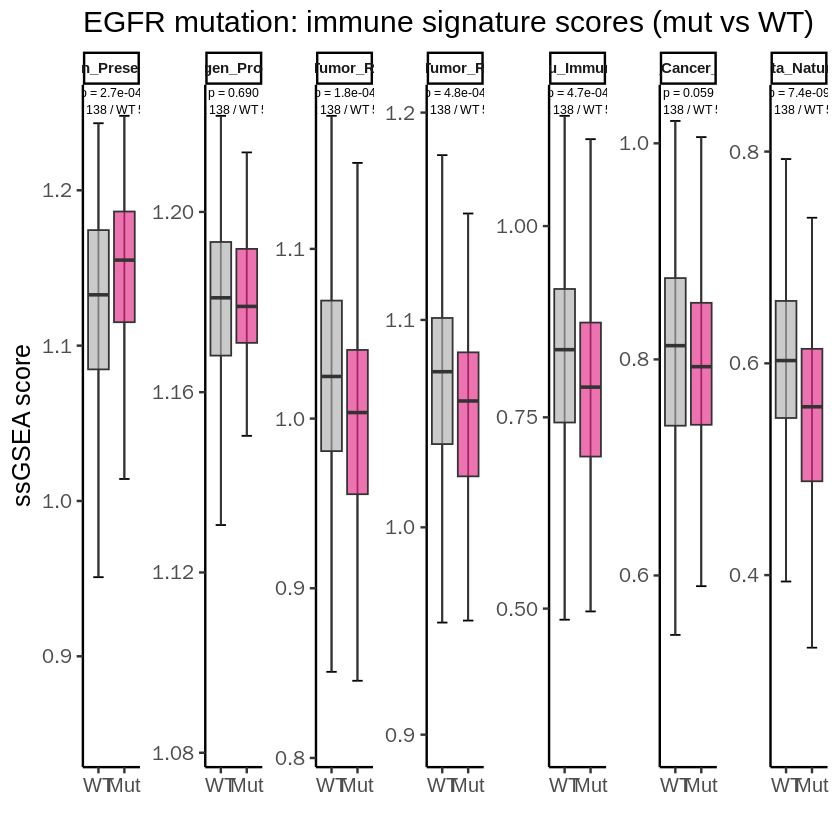

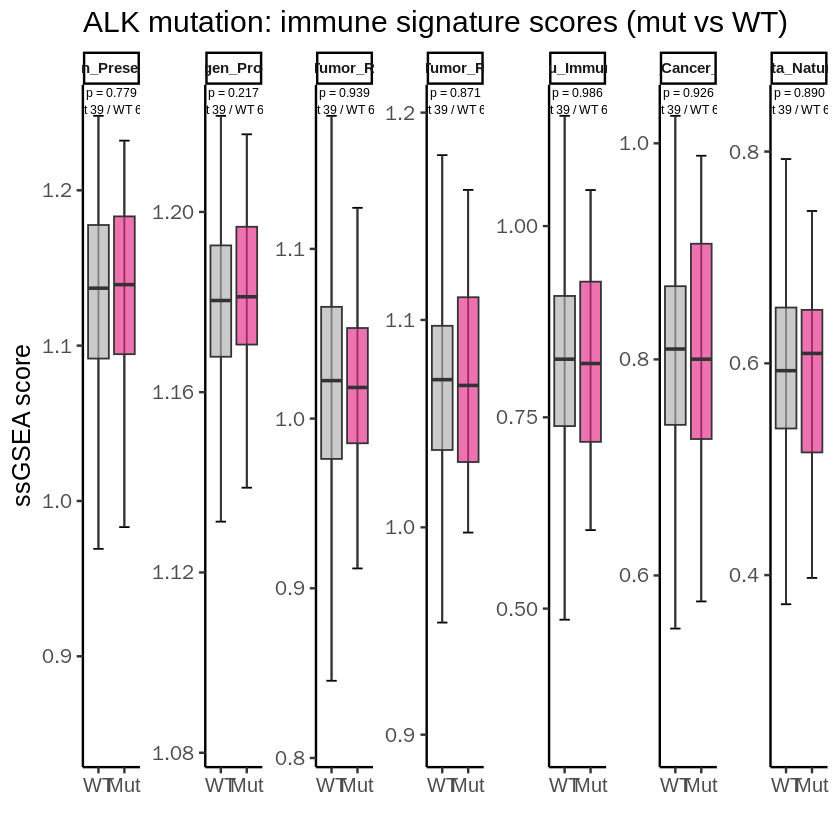

Saved: driver_group_ERBB2_mut_vs_wt.pdf


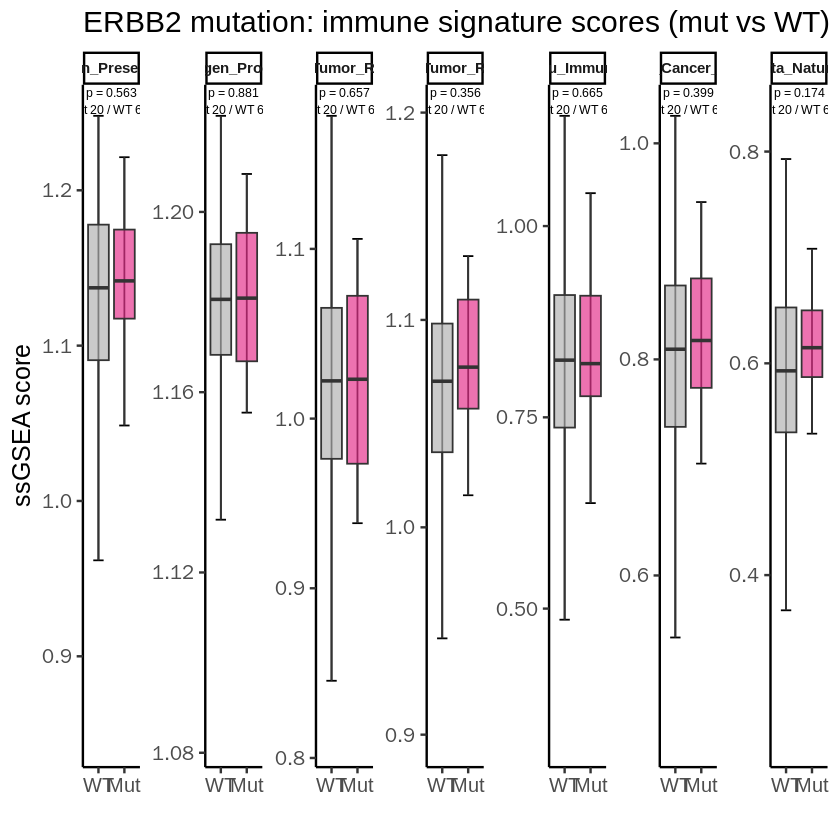

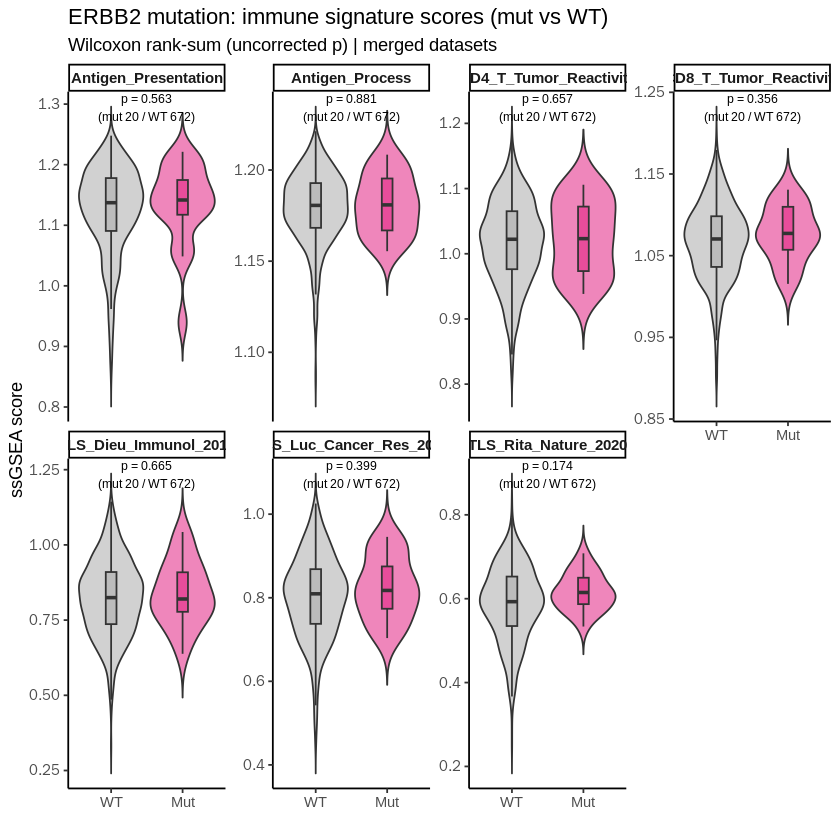

In [13]:
# ── 8. Plot per-gene mut vs WT (3 figures) ────────────────
plot_gene_mut <- function(g) {
  mc <- paste0("mut_", g)
  keep <- !is.na(dat_mut[[mc]])
  long <- do.call(rbind, lapply(sig_names, function(sig) data.frame(
    signature = sig,
    group = ifelse(dat_mut[[mc]][keep], "Mut", "WT"),
    score = dat_mut[[sig]][keep], stringsAsFactors = FALSE)))
  long$group <- factor(long$group, levels = c("WT", "Mut"))
  ann <- mut_group_df[mut_group_df$gene == g, ]
  ann$lab <- sprintf("p = %s\n(mut %d / WT %d)",
                     ifelse(ann$p_raw < 0.001, sprintf("%.1e", ann$p_raw), sprintf("%.3f", ann$p_raw)),
                     ann$n_mut, ann$n_wt)
  ann$x <- 1.5; ann$y <- Inf
  p <- ggplot(long, aes(x = group, y = score, fill = group)) +
    #geom_violin(trim = FALSE, alpha = 0.6, scale = "width") +
    stat_boxplot(geom = "errorbar",width = 0.4) +                                
    geom_boxplot(width = 0.8, outlier.shape = NA, alpha = 0.7) +
    facet_wrap(~ signature, scales = "free_y", ncol = 7) +
    scale_fill_manual(values = c("WT" = "grey70", "Mut" = "#E5368E")) +
    geom_text(data = ann, aes(x = x, y = y, label = lab),
              inherit.aes = FALSE, vjust = 1.1, size = 2.6, hjust = 0.5) +
    theme_classic(base_size = 15) +
    labs(x = "", y = "ssGSEA score",
         title = paste0(g, " mutation: immune signature scores (mut vs WT)")) +
    theme(legend.position = "none", strip.text = element_text(size = 9, face = "bold"))
  ggsave(file.path(fig_dir, '/Figures_raw/',paste0("TCGA_CPTAC_CDDP_DriverMut_", g, "_mut_vs_wt.pdf")), p,
         width = 28, height = 4.5, bg = "transparent")
  return(p)
}
for (g in genes_grp) {
  print(plot_gene_mut(g))
  cat("Saved: driver_group_", g, "_mut_vs_wt.pdf\n", sep = "")
}

---

# 9. Age and Driver Mutations Modeling (Standardized Coefficients)

**Goal:** Quantify the relationship of age and oncogenic driver status (EGFR/ALK/ERBB2 mutation + CNV) with
each immune signature using a joint linear model, and compare their effects on a **common (standardized) scale**.

**Model (per signature):**
```
score ~ scale(age) + mut_EGFR + scale(cna_EGFR) + mut_ALK + scale(cna_ALK) + mut_ERBB2 + scale(cna_ERBB2)
        + Dataset + gender + stage_simple
```

**Preprocessing:**
- `age` → z-score (per 1 SD).
- `cna_*` → capped at 10 (ASCAT absolute copy number; avoid extreme values such as ERBB2=105 dominating the scale), then z-score.
- `mut_*` → 0/1 (binary; coefficient = WT→mutant effect, already comparable).
- `Dataset` / `gender` / `stage_simple` → factors (confounders, not standardized).

**Sample scope:** complete cases across all 6 driver variables + age + Dataset + gender + stage (n = 685).

**Interpretation:** standardized coefficients are directly comparable across age and driver variables.
Age is highlighted to make "age vs driver" visually explicit.

**Caveat:** `mut_X` and `cna_X` for the same gene are correlated (e.g. EGFR amplification co-occurs with EGFR
mutation), so the joint model reports *conditional* effects; collinearity may attenuate individual coefficients.

In [14]:
# ── 9. Build complete-case design matrix (reuse Section 7's dat_complete if present) ──
suppressMessages({library(dplyr); library(stringr); library(SummarizedExperiment)})

# Rebuild dat_complete (matches v3 Cell 31) for independence
LUAD_merged <- readRDS(file.path(obj_dir, "LUAD_BulkRNA_merged.rds"))
LUAD_mut    <- readRDS(file.path(obj_dir, "LUAD_BulkRNA_merged_withMutations.rds"))
ssgsea_res  <- readRDS(file.path(obj_dir, "driver_stratified_ssgsea.rds"))
cd <- as.data.frame(colData(LUAD_merged))
cd_mut <- as.data.frame(colData(LUAD_mut))
ss_df  <- as.data.frame(ssgsea_res)

dat_full <- cbind(
  cd_mut[, c("barcode","Dataset","age","gender","ajcc_pathologic_stage")],
  ss_df
)
dat_full$mut_EGFR  <- cd_mut$mut_EGFR
dat_full$cna_EGFR  <- cd_mut$cna_EGFR
dat_full$mut_ALK   <- cd_mut$mut_ALK
dat_full$cna_ALK   <- cd_mut$cna_ALK
dat_full$mut_ERBB2 <- cd_mut$mut_ERBB2
dat_full$cna_ERBB2 <- cd_mut$cna_ERBB2

dat_full$stage_simple <- factor(dplyr::case_when(
  str_detect(dat_full$ajcc_pathologic_stage, "Stage I[^I]") ~ "Stage I",
  str_detect(dat_full$ajcc_pathologic_stage, "Stage II[^I]") ~ "Stage II",
  str_detect(dat_full$ajcc_pathologic_stage, "Stage III") ~ "Stage III",
  str_detect(dat_full$ajcc_pathologic_stage, "Stage IV") ~ "Stage IV",
  TRUE ~ "Unknown"), levels = c("Stage I","Stage II","Stage III","Stage IV","Unknown"))
dat_full$gender <- factor(ifelse(is.na(dat_full$gender) | dat_full$gender == "", "Unknown", dat_full$gender))

dat_complete <- dat_full %>%
  filter(complete.cases(mut_EGFR, cna_EGFR, mut_ALK, cna_ALK, mut_ERBB2, cna_ERBB2),
         !is.na(age), !is.na(Dataset), !is.na(gender), !is.na(stage_simple))
# ensure mut_* numeric 0/1
dat_complete$mut_EGFR  <- as.numeric(as.logical(dat_complete$mut_EGFR))
dat_complete$mut_ALK   <- as.numeric(as.logical(dat_complete$mut_ALK))
dat_complete$mut_ERBB2 <- as.numeric(as.logical(dat_complete$mut_ERBB2))

sig_names <- colnames(ss_df)
driver_genes <- c("EGFR","ALK","ERBB2")

# standardize predictors
CAP <- 10
dat_complete$age_z <- as.numeric(scale(dat_complete$age))
for (g in driver_genes) {
  capped <- pmin(dat_complete[[paste0("cna_", g)]], CAP)
  dat_complete[[paste0("cna_", g, "_z")]] <- as.numeric(scale(capped))
}

cat("Complete-case sample:", nrow(dat_complete), "\n")
cat("Datasets:\n"); print(table(dat_complete$Dataset))

Complete-case sample: 685 
Datasets:

CDDP_EAGLE      CPTAC  TCGA_LUAD 
        40        197        448 


Datasets:



CDDP_EAGLE      CPTAC  TCGA_LUAD 
        40        197        448 


In [15]:
# ── 9. Fit joint linear model, extract standardized coefficients ──
predictor_terms <- c("age_z",
                     "mut_EGFR","cna_EGFR_z","mut_ALK","cna_ALK_z","mut_ERBB2","cna_ERBB2_z")

coef_results <- list()
for (sig in sig_names) {
  f <- as.formula(paste0("`", sig, "` ~ age_z + mut_EGFR + cna_EGFR_z + mut_ALK + cna_ALK_z + mut_ERBB2 + cna_ERBB2_z + Dataset + gender + stage_simple"))
  fit <- lm(f, data = dat_complete)
  sm  <- summary(fit)$coefficients
  for (term in predictor_terms) {
    if (term %in% rownames(sm)) {
      coef_results[[length(coef_results)+1]] <- data.frame(
        signature=sig, term=term, estimate=sm[term,"Estimate"],
        se=sm[term,"Std. Error"], p_value=sm[term,"Pr(>|t|)"], stringsAsFactors=FALSE)
    }
  }
}
coef_df <- do.call(rbind, coef_results)
coef_df$ci_lo <- coef_df$estimate - 1.96*coef_df$se
coef_df$ci_hi <- coef_df$estimate + 1.96*coef_df$se
coef_df$type  <- ifelse(coef_df$term == "age_z", "Age", "Driver")
coef_df$label <- dplyr::case_when(
  coef_df$term == "age_z"       ~ "Age (z)",
  coef_df$term == "mut_EGFR"    ~ "EGFR mut",
  coef_df$term == "cna_EGFR_z"  ~ "EGFR CNV (z)",
  coef_df$term == "mut_ALK"     ~ "ALK mut",
  coef_df$term == "cna_ALK_z"   ~ "ALK CNV (z)",
  coef_df$term == "mut_ERBB2"   ~ "ERBB2 mut",
  coef_df$term == "cna_ERBB2_z" ~ "ERBB2 CNV (z)", TRUE ~ coef_df$term)
coef_df$label <- factor(coef_df$label,
  levels = c("Age (z)","EGFR mut","EGFR CNV (z)","ALK mut","ALK CNV (z)","ERBB2 mut","ERBB2 CNV (z)"))
coef_df$is_sig <- coef_df$p_value < 0.05

cat("Standardized coefficients (joint linear model), n =", nrow(dat_complete), ":\n\n")
print(coef_df[order(coef_df$signature, coef_df$label), c("signature","label","estimate","se","p_value")],
      row.names = FALSE)

saveRDS(coef_df, file.path(obj_dir, "driver_group_std_coef.rds"))
write.csv(coef_df, file.path(obj_dir, "driver_group_std_coef.csv"), row.names = FALSE)
cat("\nSaved: driver_group_std_coef.rds / .csv\n")

Standardized coefficients (joint linear model), n = 685 :

               signature         label      estimate           se      p_value
    Antigen_Presentation       Age (z)  0.0107828564 0.0024787500 1.572339e-05
    Antigen_Presentation      EGFR mut  0.0238436079 0.0069190516 6.042460e-04
    Antigen_Presentation  EGFR CNV (z)  0.0007162188 0.0031932495 8.225987e-01
    Antigen_Presentation       ALK mut  0.0088553777 0.0106580400 4.063462e-01
    Antigen_Presentation   ALK CNV (z) -0.0110252741 0.0036539128 2.646146e-03
    Antigen_Presentation     ERBB2 mut  0.0111645724 0.0147308243 4.487737e-01
    Antigen_Presentation ERBB2 CNV (z)  0.0002762942 0.0034217723 9.356681e-01
         Antigen_Process       Age (z)  0.0013905825 0.0006856843 4.295264e-02
         Antigen_Process      EGFR mut -0.0001661670 0.0019139829 9.308426e-01
         Antigen_Process  EGFR CNV (z)  0.0002694814 0.0008833328 7.604048e-01
         Antigen_Process       ALK mut  0.0043430164 0.0029482807 1.4120

               signature         label      estimate           se      p_value
    Antigen_Presentation       Age (z)  0.0107828564 0.0024787500 1.572339e-05
    Antigen_Presentation      EGFR mut  0.0238436079 0.0069190516 6.042460e-04
    Antigen_Presentation  EGFR CNV (z)  0.0007162188 0.0031932495 8.225987e-01
    Antigen_Presentation       ALK mut  0.0088553777 0.0106580400 4.063462e-01
    Antigen_Presentation   ALK CNV (z) -0.0110252741 0.0036539128 2.646146e-03
    Antigen_Presentation     ERBB2 mut  0.0111645724 0.0147308243 4.487737e-01
    Antigen_Presentation ERBB2 CNV (z)  0.0002762942 0.0034217723 9.356681e-01
         Antigen_Process       Age (z)  0.0013905825 0.0006856843 4.295264e-02
         Antigen_Process      EGFR mut -0.0001661670 0.0019139829 9.308426e-01
         Antigen_Process  EGFR CNV (z)  0.0002694814 0.0008833328 7.604048e-01
         Antigen_Process       ALK mut  0.0043430164 0.0029482807 1.412018e-01
         Antigen_Process   ALK CNV (z) -0.0016430356


Saved: driver_group_std_coef.rds / .csv


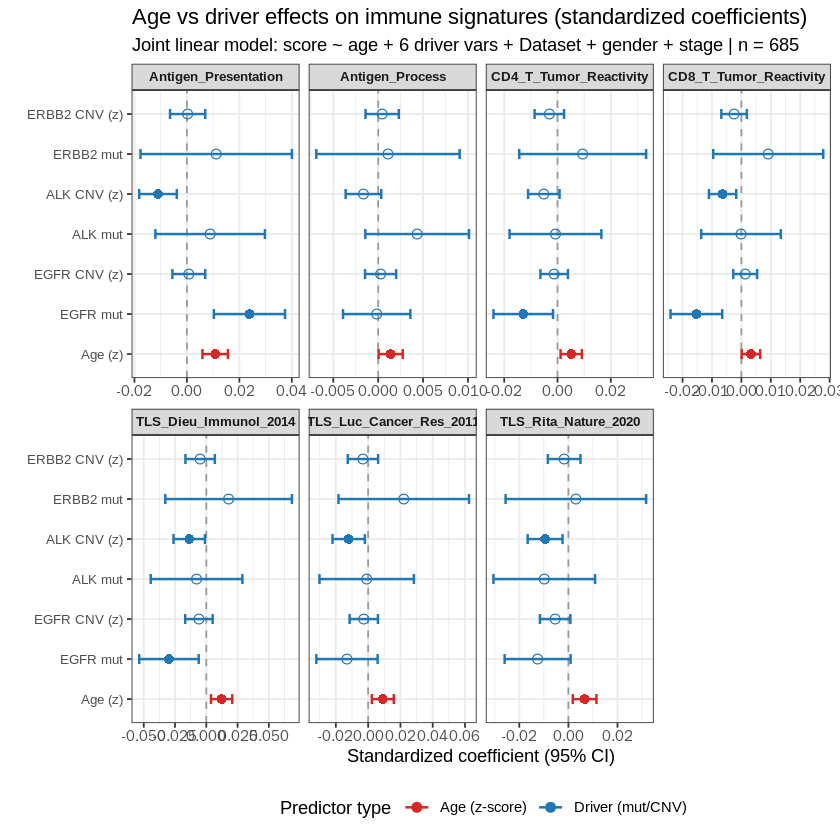

Saved: driver_group_std_coef_forest.png, driver_group_std_coef_rank.png


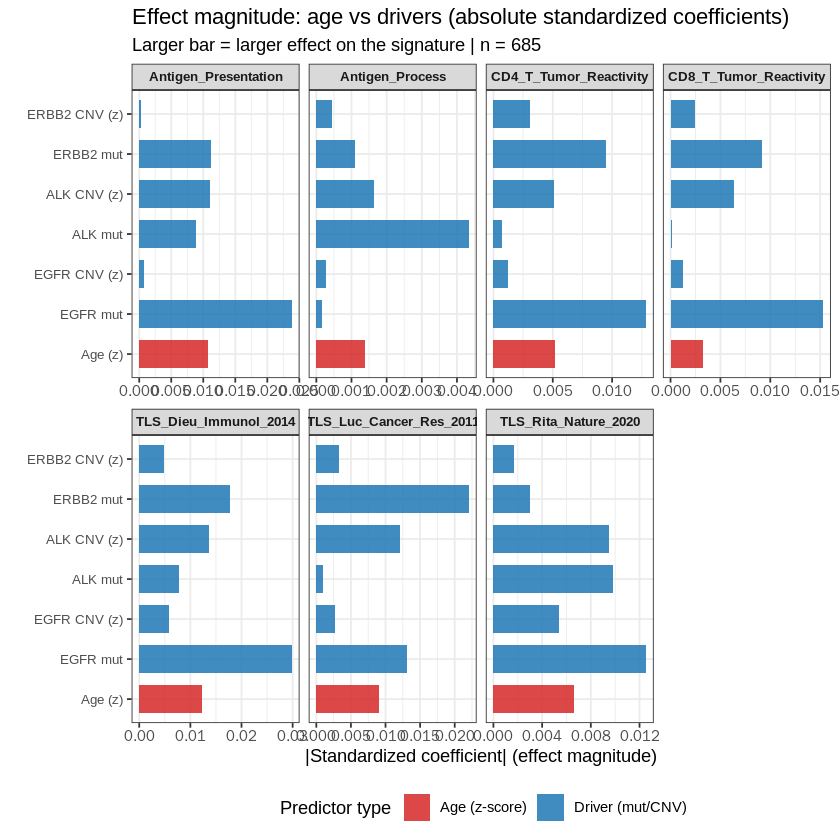

In [17]:
# ── 9. Forest plot (age highlighted) + magnitude rank plot ──
suppressMessages(library(ggplot2))

# Forest plot
p_forest <- ggplot(coef_df, aes(x = estimate, y = label)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey60") +
  geom_errorbarh(aes(xmin = ci_lo, xmax = ci_hi, color = type), height = 0.25, linewidth = 0.7) +
  geom_point(aes(color = type, shape = is_sig), size = 2.4) +
  facet_wrap(~ signature, scales = "free_x", ncol = 4) +
  scale_color_manual(values = c("Age" = "#D62728", "Driver" = "#1F77B4"),
                     labels = c("Age (z-score)", "Driver (mut/CNV)")) +
  scale_shape_manual(values = c("FALSE" = 1, "TRUE" = 16), guide = "none") +
  labs(x = "Standardized coefficient (95% CI)", y = "",
       title = "Age vs driver effects on immune signatures (standardized coefficients)",
       subtitle = "Joint linear model: score ~ age + 6 driver vars + Dataset + gender + stage | n = 685",
       color = "Predictor type") +
  theme_bw(base_size = 11) +
  theme(legend.position = "bottom", strip.text = element_text(size = 8, face = "bold"),
        axis.text.y = element_text(size = 8))
ggsave(file.path(fig_dir, '/Figures_raw/',paste0("TCGA_CPTAC_CDDP_DriverMut_GLM_Coeff_ForesetPlot.pdf")), p_forest,
         width = 28, height = 10, bg = "transparent")
print(p_forest)

# Magnitude rank plot
coef_df$abs_est <- abs(coef_df$estimate)
p_rank <- ggplot(coef_df, aes(x = abs_est, y = label, fill = type)) +
  geom_col(width = 0.7, alpha = 0.85) +
  facet_wrap(~ signature, scales = "free_x", ncol = 4) +
  scale_fill_manual(values = c("Age" = "#D62728", "Driver" = "#1F77B4"),
                    labels = c("Age (z-score)", "Driver (mut/CNV)")) +
  labs(x = "|Standardized coefficient| (effect magnitude)", y = "",
       title = "Effect magnitude: age vs drivers (absolute standardized coefficients)",
       subtitle = "Larger bar = larger effect on the signature | n = 685", fill = "Predictor type") +
  theme_bw(base_size = 11) +
  theme(legend.position = "bottom", strip.text = element_text(size = 8, face = "bold"),
        axis.text.y = element_text(size = 8))

ggsave(file.path(fig_dir, '/Figures_raw/',paste0("TCGA_CPTAC_CDDP_DriverMut_GLM_Coeff_Barplot.pdf")), p_rank,
         width = 28, height = 10, bg = "transparent")

print(p_rank)
cat("Saved: driver_group_std_coef_forest.png, driver_group_std_coef_rank.png\n")

---

# 10. Stratified Analysis: Age Effect in Driver-Negative Samples

**Purpose:** EO-LUAD is enriched in EGFR/ALK/ERBB2 drivers, which themselves associate with a "cold" immune
microenvironment. To test whether the observed age-associated immune phenotypes are driven by **age per se**
rather than **driver-associated biology**, re-fit the model **restricted to driver-negative cases**.

**Definition of driver-negative:** for each of EGFR/ALK/ERBB2, `mut == 0` (no non-silent mutation) AND
`cna == 2` (diploid; any CNV aberration cna≠2 counts as driver-positive).

**Model (linear, per signature, in driver-negative subset):**
```
score ~ age + Dataset + gender + stage_simple
```

**Comparison:** age effect in driver-negative subset vs full cohort (with driver covariates in model).
Note the driver-negative subset is small (n ≈ 121); the result should be interpreted with the corresponding
reduction in statistical power in mind (an inconclusive null, not evidence of no age effect).

In [6]:
# ── 10. Driver-negative stratified analysis ────────────────
suppressMessages({library(dplyr)})

# driver-negative flag (raw cna == 2, mut == 0 for all 3 genes)
dat_complete$driver_neg <- with(dat_complete,
  (mut_EGFR == 0 & cna_EGFR == 2) &
  (mut_ALK  == 0 & cna_ALK  == 2) &
  (mut_ERBB2== 0 & cna_ERBB2== 2))

cat("driver-negative n =", sum(dat_complete$driver_neg, na.rm=TRUE), "of", nrow(dat_complete), "\n\n")

dn <- dat_complete[dat_complete$driver_neg, ]

# age effect in driver-negative (linear, raw age)
neg_age <- list()
for (sig in sig_names) {
  f <- lm(as.formula(paste0("`", sig, "` ~ age + Dataset + gender + stage_simple")), data = dn)
  sm <- summary(f)$coefficients
  neg_age[[sig]] <- data.frame(signature=sig,
                               age_coef=sm["age","Estimate"], age_se=sm["age","Std. Error"],
                               age_p=sm["age","Pr(>|t|)"], n=nrow(dn))
}
neg_age_df <- do.call(rbind, neg_age)
neg_age_df$ci_lo <- neg_age_df$age_coef - 1.96*neg_age_df$age_se
neg_age_df$ci_hi <- neg_age_df$age_coef + 1.96*neg_age_df$age_se

# full-cohort age effect (with driver covariates) for comparison
full_age <- list()
for (sig in sig_names) {
  f <- lm(as.formula(paste0("`", sig, "` ~ age + mut_EGFR + cna_EGFR_z + mut_ALK + cna_ALK_z + mut_ERBB2 + cna_ERBB2_z + Dataset + gender + stage_simple")), data = dat_complete)
  sm <- summary(f)$coefficients
  full_age[[sig]] <- data.frame(signature=sig,
                                age_coef=sm["age","Estimate"], age_se=sm["age","Std. Error"],
                                age_p=sm["age","Pr(>|t|)"], n=nrow(dat_complete))
}
full_age_df <- do.call(rbind, full_age)
full_age_df$ci_lo <- full_age_df$age_coef - 1.96*full_age_df$age_se
full_age_df$ci_hi <- full_age_df$age_coef + 1.96*full_age_df$age_se

cat("=== Age effect (per 1 year) in driver-negative vs full cohort ===\n\n")
cmp <- merge(full_age_df, neg_age_df, by="signature", suffixes=c("_full","_neg"))
print(cmp[, c("signature","age_coef_full","age_p_full","age_coef_neg","age_p_neg")], row.names=FALSE)

saveRDS(neg_age_df, file.path(obj_dir, "driver_negative_age_effect.rds"))
write.csv(neg_age_df, file.path(obj_dir, "driver_negative_age_effect.csv"), row.names=FALSE)
cat("\nSaved: driver_negative_age_effect.rds / .csv\n")

driver-negative n = 121 of 685 



=== Age effect (per 1 year) in driver-negative vs full cohort ===



               signature age_coef_full   age_p_full age_coef_neg  age_p_neg
    Antigen_Presentation  0.0011057092 1.572339e-05 1.204420e-03 0.05104455
         Antigen_Process  0.0001425949 4.295264e-02 4.066203e-05 0.83472697
  CD4_T_Tumor_Reactivity  0.0005284267 1.195034e-02 3.949054e-04 0.47188970
  CD8_T_Tumor_Reactivity  0.0003323056 4.394222e-02 5.239163e-04 0.23730900
   TLS_Dieu_Immunol_2014  0.0012554941 4.993166e-03 1.458968e-03 0.22771855
 TLS_Luc_Cancer_Res_2011  0.0009331353 8.963593e-03 8.438880e-04 0.36215882
    TLS_Rita_Nature_2020  0.0006770649 7.402591e-03 2.190047e-04 0.76221839



Saved: driver_negative_age_effect.rds / .csv


Saved: driver_negative_age_effect_compare.png


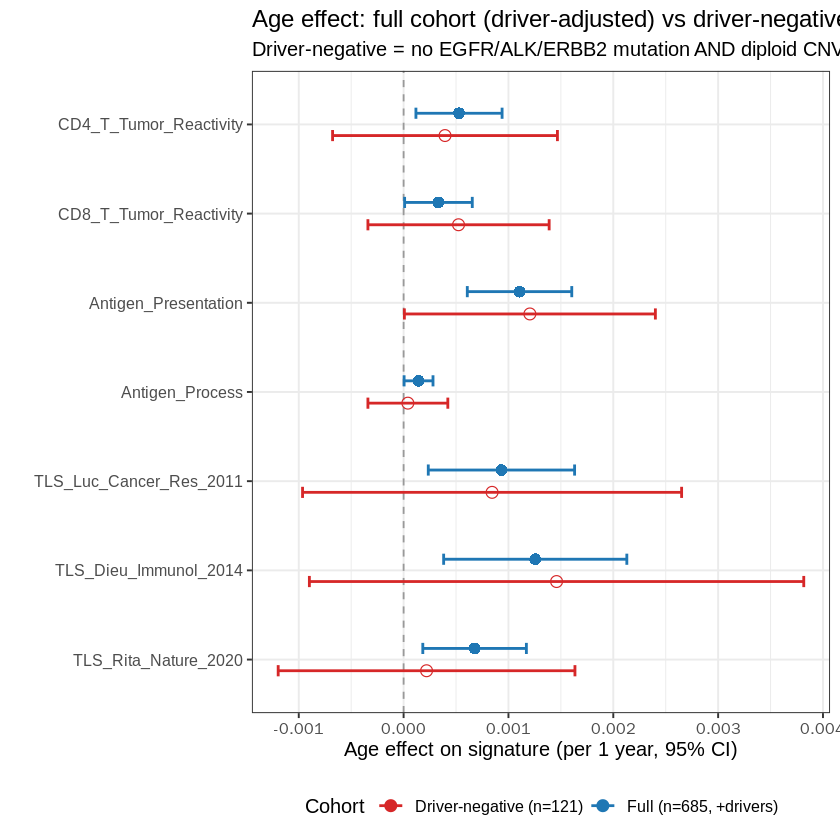

In [7]:
# ── 10. Comparison plot: full cohort vs driver-negative age effect ──
suppressMessages(library(ggplot2))

cmp_long <- rbind(
  data.frame(signature = full_age_df$signature, cohort = "Full (n=685, +drivers)",
             coef = full_age_df$age_coef, lo = full_age_df$ci_lo, hi = full_age_df$ci_hi,
             p = full_age_df$age_p),
  data.frame(signature = neg_age_df$signature, cohort = "Driver-negative (n=121)",
             coef = neg_age_df$age_coef, lo = neg_age_df$ci_lo, hi = neg_age_df$ci_hi,
             p = neg_age_df$age_p)
)
cmp_long$signature <- factor(cmp_long$signature, levels = sig_names)
cmp_long$is_sig <- cmp_long$p < 0.05

p_cmp <- ggplot(cmp_long, aes(x = coef, y = signature, color = cohort)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey60") +
  geom_errorbarh(aes(xmin = lo, xmax = hi), height = 0.25, linewidth = 0.8,
                 position = position_dodge(width = 0.5)) +
  geom_point(aes(shape = is_sig), size = 3, position = position_dodge(width = 0.5)) +
  scale_color_manual(values = c("Full (n=685, +drivers)" = "#1F77B4",
                                "Driver-negative (n=121)" = "#D62728"), name = "Cohort") +
  scale_shape_manual(values = c("FALSE" = 1, "TRUE" = 16), guide = "none") +
  labs(x = "Age effect on signature (per 1 year, 95% CI)", y = "",
       title = "Age effect: full cohort (driver-adjusted) vs driver-negative",
       subtitle = "Driver-negative = no EGFR/ALK/ERBB2 mutation AND diploid CNV | filled = p<0.05") +
  theme_bw(base_size = 12) +
  theme(legend.position = "bottom")

ggsave(file.path(fig_dir, "driver_negative_age_effect_compare.png"), p_cmp,
       width = 11, height = 6, dpi = 200, bg = "white")
print(p_cmp)
cat("Saved: driver_negative_age_effect_compare.png\n")